In [94]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
import pandas as pd
import polars as pl
import numpy as np 

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
import umap.umap_ as umap

import timeit

from functions import (
    apply_correlation_to_df,
    normalize_column,
    z_score_column,
    safe_divide,
    classify_income_group,
    compute_energy_mix_shares,
    plot_dual_axis_timeseries,
    run_kmeans_elbow,
    get_top_bottom_n
)

# professional theme: clean white grid with muted palette
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "figure.titlesize": 16,
})
%matplotlib inline

## Setup

Import libraries and configure plot styling. We use `seaborn` for statistical graphics with a clean whitegrid theme, and `autoreload` to hot-reload helper functions from [functions.py](functions.py) during development.

# Carbon Emissions and Economic Development: A Visual Analysis

The central question driving this analysis is whether economic growth necessarily comes at the cost of rising carbon emissions - or whether countries can **decouple** the two. This is one of the most consequential questions in climate policy: if decoupling is possible, it suggests that prosperity and sustainability are not mutually exclusive.

To investigate this, we combine two authoritative datasets:

1. **CO2 Emissions** (Our World in Data, 1750–2024) - historical emissions by country, measured in millions of tonnes
2. **GDP** (World Bank, 1960–2024) - economic output in current USD
3. **Electricity** (Our World in Data, 2000-2024) - Share of electricity production methods of the countries

By normalizing both metrics to per-capita values and computing Pearson correlations over time, we can classify countries along a spectrum: from those where growth and emissions move in lockstep (strong coupling) to those where GDP continues to rise while emissions fall (decoupling). We then ask whether this pattern is systematic - do high-income countries decouple more than low-income ones?

## CO2 Emissions Data

We load the Our World in Data CO2 dataset, which contains 79 columns spanning energy mix, land use, and emissions breakdowns. For this analysis we reduce it to five key variables: `country`, `year`, `iso_code`, `population`, and `co2` (total production-based CO2 emissions in millions of tonnes).

Two important filtering steps:
- **Drop rows without `iso_code`**: The dataset includes aggregate entities like "Africa", "OECD", and "World" that lack ISO country codes. Removing these ensures we work exclusively with individual nation-states.
- **Filter to post-1960**: GDP data from the World Bank only begins in 1960, so we align the time range to enable a clean merge later.

In [96]:
co2_df = pl.read_csv('../data/co2_data.csv')

# choose what columns to keep (can be changed, but this is the most important)
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']

# drop the columns that are not in the selected_columns list
co2_df = co2_df.select(selected_columns)

# remove entries with no iso code(Continents and other groups)
co2_df = (
    co2_df
    .with_columns(pl.col("co2")
                    .str.strip_chars()
                    .replace("", None)
                    .cast(pl.Float64))
    
    .filter(pl.col("iso_code") != "")
    .filter(pl.col("year") > 1960))


co2_df


country,year,iso_code,population,co2
str,i64,str,i64,f64
"""Afghanistan""",1961,"""AFG""",9214082,0.491
"""Afghanistan""",1962,"""AFG""",9404410,0.689
"""Afghanistan""",1963,"""AFG""",9604491,0.707
"""Afghanistan""",1964,"""AFG""",9814317,0.839
"""Afghanistan""",1965,"""AFG""",10036003,1.007
…,…,…,…,…
"""Zimbabwe""",2020,"""ZWE""",15526887,8.491
"""Zimbabwe""",2021,"""ZWE""",15797220,10.223
"""Zimbabwe""",2022,"""ZWE""",16069061,12.232


## GDP Data

The World Bank GDP dataset arrives in **wide format** - one column per year (1960, 1961, ..., 2024). This is convenient for spreadsheet viewing but incompatible with tidy-data principles needed for plotting and merging. We use `pl.unipivot()` to reshape it into long format with one row per country-year observation.

Key steps:
- **Melt** year columns into `year` (int) and `gdp` (numeric) columns
- **Rename** `Country Code` to `iso_code` to create a shared merge key with the CO2 dataset
- **Drop missing GDP values** - not all countries have GDP records for every year, particularly in earlier decades or for newly independent states

In [97]:
# load GDP data
gdp_df = pl.read_csv('../data/gdp_data.csv')

# reshape from wide to long format
# melt the year columns into rows
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_df = gdp_df.unpivot(
    index=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    on=year_columns,
    variable_name='year',
    value_name='gdp')

# rename Country Code to iso_code for merging
gdp_df = gdp_df.rename({'Country Code': 'iso_code'})

# keep only the columns we need
gdp_df = gdp_df[['iso_code', 'year', 'gdp']]

gdp_df = (gdp_df
          .with_columns(pl.col("year").str.to_integer())
          .with_columns(pl.col("gdp").str.strip_chars().replace("", None).cast(pl.Float64))
          .drop_nulls(subset=["gdp"]))

gdp_df

iso_code,year,gdp
str,i64,f64
"""AFE""",1960,2.4206e10
"""AFW""",1960,1.1905e10
"""ARG""",1960,1.5865e10
"""AUS""",1960,1.8636e10
"""AUT""",1960,6.6241e9
…,…,…
"""WSM""",2024,1.1757e9
"""XKX""",2024,1.1197e10
"""ZAF""",2024,4.0114e11


## Merging the Datasets

We perform a **left join** of GDP onto the CO2 dataframe using `iso_code` and `year` as composite keys. A left join preserves every CO2 record and attaches GDP where available - countries or years without World Bank GDP data simply receive NaN. This is preferable to an inner join because it avoids silently discarding emission records that are still valuable for other analyses.

### Missing Data Heatmap

Before proceeding, we visualize data completeness. The heatmap below shows each variable as a column and each record as a row, with bright cells indicating missing values. This diagnostic is important because it reveals whether missingness is **random** or **systematic** - for instance, GDP data may be consistently absent for certain countries or time periods, which would bias any analysis that silently drops incomplete rows.

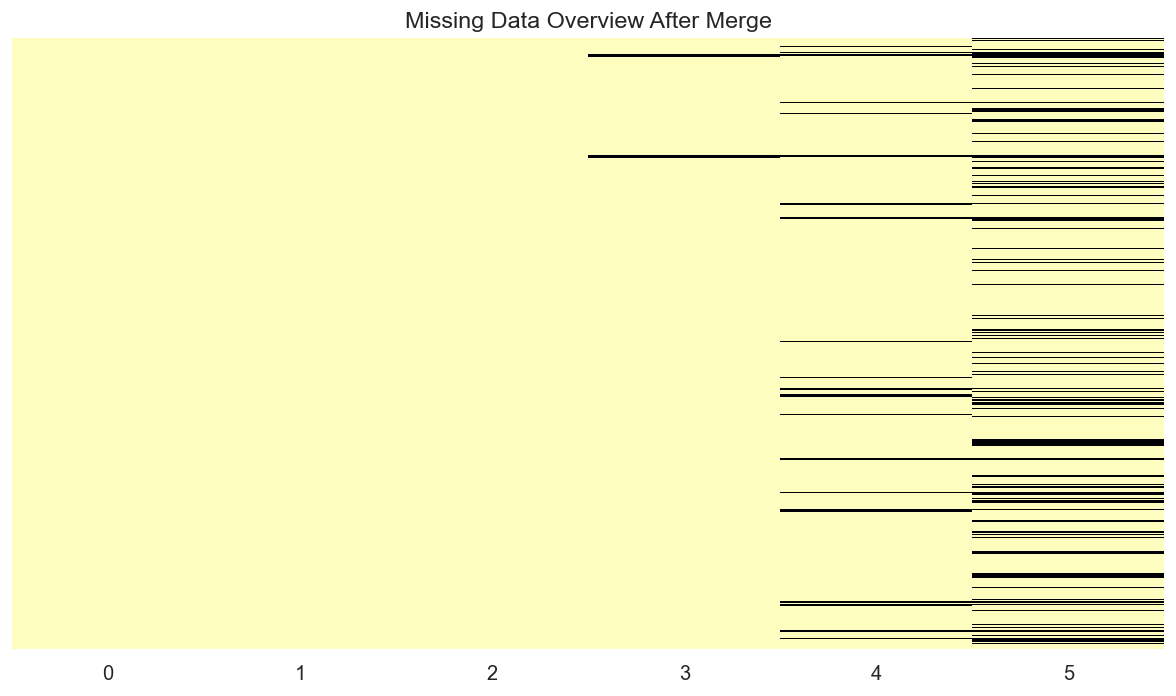

In [98]:
# merge the datasets on iso_code and year
base_df = co2_df.join(
    gdp_df,
    on=['iso_code', 'year'],
    how='left',)

# missing data heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(base_df.select(pl.all().is_null()), yticklabels=False, cbar=False, cmap='magma_r', ax=ax)
ax.set_title("Missing Data Overview After Merge")

plt.tight_layout()
plt.show()

In [99]:
# return null values per column
base_df.select(pl.all().null_count())

country,year,iso_code,population,co2,gdp
u32,u32,u32,u32,u32,u32
0,0,0,128,677,2745


### Data Quality Summary

The GDP column shows the most missingness - this is expected since many countries (especially newly independent or conflict-affected states) lack World Bank GDP records in earlier decades. Importantly, the missingness is **systematic** rather than random: it concentrates in specific countries and time periods. This means any analysis involving GDP will implicitly exclude these observations, so conclusions are most robust for the subset of countries with consistent economic data.

## Per-Capita Metrics

Absolute CO2 and GDP figures are dominated by population size - China and India will always top the charts simply because they have the most people, not necessarily because their economies or industries are more carbon-intensive on a per-person basis. Dividing by population yields **per-capita** values that enable fairer cross-country comparisons: how much does the average citizen emit, and how wealthy is the average citizen?

- **CO2 per capita** is expressed in **tonnes per person** (the raw CO2 column is in millions of tonnes, so we multiply by 10⁶ before dividing by population).
- **GDP per capita** is in **current USD per person**.

We use `np.divide` with a `where` guard to handle zero or missing population entries without raising division errors.

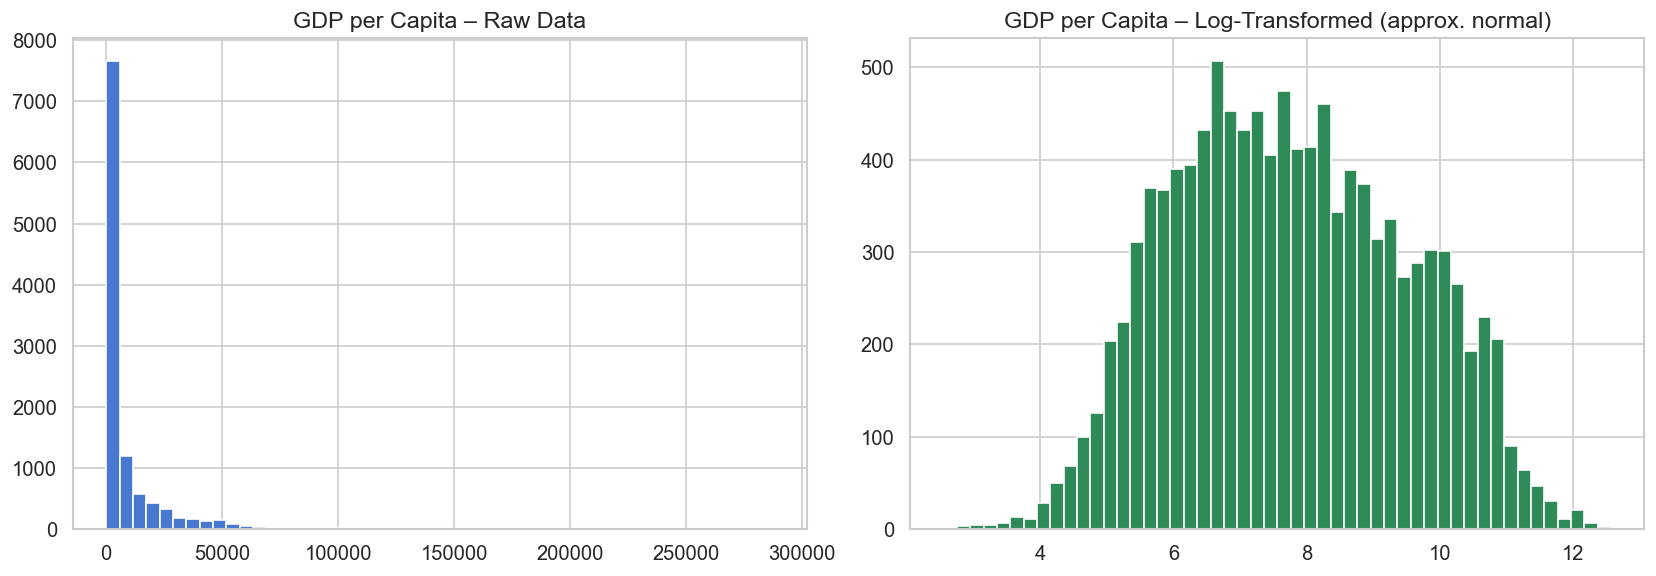

In [100]:
# CO2 is in millions of tonnes; multiply by 1e6 to get tonnes, then divide by population
base_df = base_df.with_columns(
    (pl.col("co2") / pl.col("population") * 1e6)
    .replace([float("inf"), -float("inf")], None)
    .alias("co2_per_capita"))

base_df = base_df.with_columns(
    (pl.col("gdp") / pl.col("population"))
    .replace([float("inf"), -float("inf")], None)
    .alias("gdp_per_capita"))

# Log-transform per-capita metrics for better visualization
base_df = base_df.with_columns(np.log1p(pl.col('gdp_per_capita'))
                               .alias("log_gdp_pc"))
base_df = base_df.with_columns(np.log1p(pl.col('co2_per_capita'))
                              .alias("log_co2_pc"))                     

# compare raw and log-transformed data as histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(base_df.select("gdp_per_capita"), bins=50, edgecolor='white')
axes[0].set_title('GDP per Capita – Raw Data')
axes[1].hist(base_df.select("log_gdp_pc"), bins=50, edgecolor='white', color='seagreen')
axes[1].set_title('GDP per Capita – Log-Transformed (approx. normal)')

plt.tight_layout()
plt.show()


# Analysis: Distribution and transformation of the GDP-per-capita

- **Raw-Data(Left)**: The distribution leans strongly left. Majority of the countries are in the lower income groups, while a few very rich countries form a sort of tail.

- **Log-Transformation (Right)**: By using log(x) the distribution becomes closer to the Gaussian Normal Distribution. That way we can weigh relative differences of the countries equally.


# Correlation Analysis

To quantify the relationship between economic growth and carbon emissions, we compute the **Pearson correlation coefficient** (r) between GDP per capita and CO2 per capita for each country across its full available time series.

- **r close to +1** indicates strong coupling - GDP and emissions rise together, typical of industrializing economies reliant on fossil fuels.
- **r close to 0** suggests no linear relationship - the two metrics move independently.
- **r < 0** indicates **decoupling** - GDP continues to grow while emissions decline, often driven by transitions to services-based economies, renewable energy adoption, or efficiency gains.

A minimum of 5 data points per country is required to compute a meaningful correlation; countries with fewer observations are excluded. It is worth noting that Pearson r captures only *linear* association - a country that industrialized heavily, peaked, and then decoupled will show a moderate positive r despite having a clear structural break in its emission trajectory.

In [101]:
base_df = apply_correlation_to_df(base_df)

# Finland
country = 'Finland'
sel_df = base_df.filter(pl.col("country") == country)

# fit a linear trend line
x = sel_df["gdp_per_capita"].to_numpy()
y = sel_df["co2_per_capita"].to_numpy()

slope, intercept = np.polyfit(x, y, deg=1)
print(f"Trend: CO2_pc = {slope:.6f} × GDP_pc + {intercept:.2f}")

sel_df

Trend: CO2_pc = 0.000020 × GDP_pc + 9.06


country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,correlation
str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64
"""Finland""",1961,"""FIN""",4460998,14.922,5.9844e9,3.344991,1341.501111,7.20229,1.469024,0.151857
"""Finland""",1962,"""FIN""",4491739,16.794,6.4078e9,3.738864,1426.573548,7.263731,1.555797,0.151857
"""Finland""",1963,"""FIN""",4523897,19.336,6.9589e9,4.274191,1538.257071,7.339055,1.662825,0.151857
"""Finland""",1964,"""FIN""",4549092,22.831,7.8490e9,5.018804,1725.396583,7.453792,1.794889,0.151857
"""Finland""",1965,"""FIN""",4564150,25.3,8.6804e9,5.543201,1901.864277,7.551116,1.878426,0.151857
…,…,…,…,…,…,…,…,…,…,…
"""Finland""",2020,"""FIN""",5529616,37.72,2.7000e11,6.82145,48828.040068,10.79608,2.05687,0.151857
"""Finland""",2021,"""FIN""",5541069,37.82,2.9422e11,6.825398,53098.636833,10.879925,2.057375,0.151857
"""Finland""",2022,"""FIN""",5569300,36.337,2.8025e11,6.524518,50321.063564,10.826199,2.018167,0.151857


## Country-Level Analysis: GDP vs CO2 Over Time

The dual-axis line plot below overlays GDP per capita and CO2 per capita for a selected country on a shared timeline. Two independent y-axes are necessary because the two metrics operate on vastly different scales (dollars vs. tonnes), but their *temporal trajectories* are directly comparable.

This visualization directly tests the core question of the analysis:
- **Parallel upward trends** indicate that the economy remains carbon-intensive - growth is fuelled by fossil energy.
- **Diverging trends** (GDP rising, CO2 flattening or declining) are evidence of **decoupling**, often driven by shifts toward service economies, renewable energy, or industrial efficiency.

The annotated Pearson r value provides a single-number summary of the visual relationship.

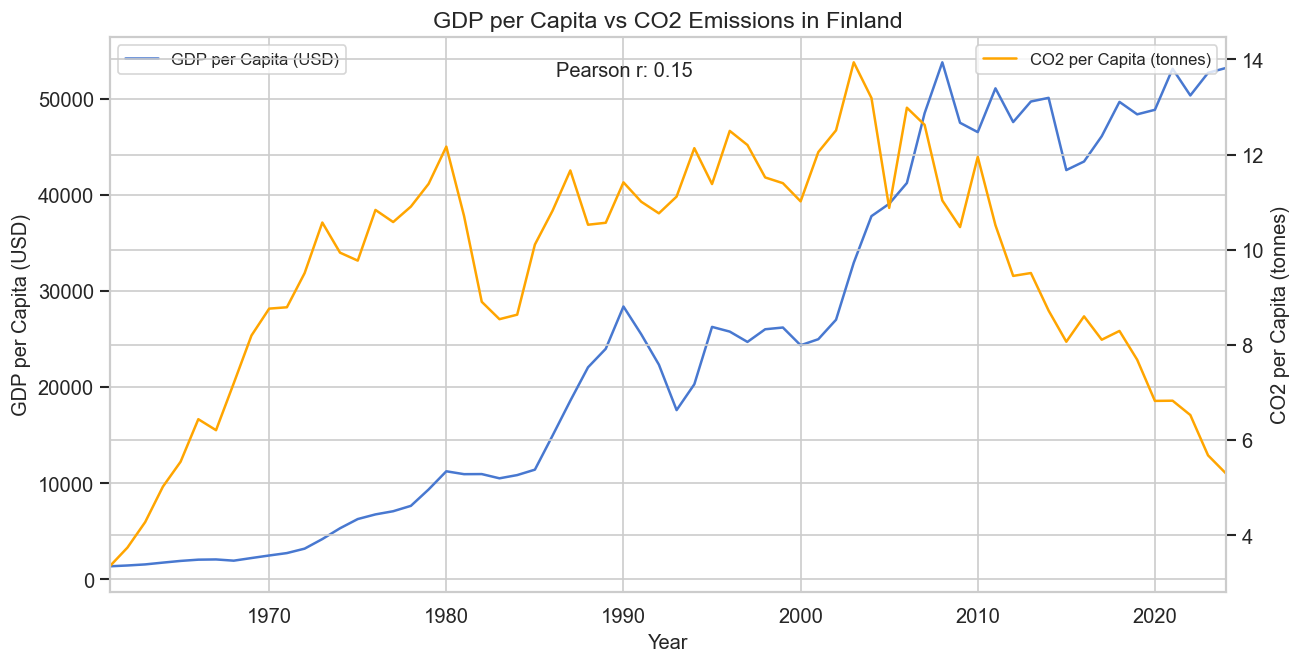

In [102]:
plot_dual_axis_timeseries(
    df=sel_df,
    x_col='year',
    y1_col='gdp_per_capita',
    y2_col='co2_per_capita',
    y1_label='GDP per Capita (USD)',
    y2_label='CO2 per Capita (tonnes)',
    title=f'GDP per Capita vs CO2 Emissions in {country}',
    correlation_value=sel_df.select(pl.col("correlation").last()).item()
)

### Global Averages: CO2 per Capita vs GDP per Capita Over Time

Before zooming into individual countries, we first examine the **global average** trajectories. The dual-axis line plot below overlays the mean CO2 per capita (left axis, blue) and mean GDP per capita (right axis, orange) across all countries for each year.

This view reveals the macro-level tension: global GDP per capita has risen steadily since 1960, while average CO2 per capita shows signs of plateauing or declining in recent decades - suggesting that **aggregate decoupling** may already be underway at the global level.

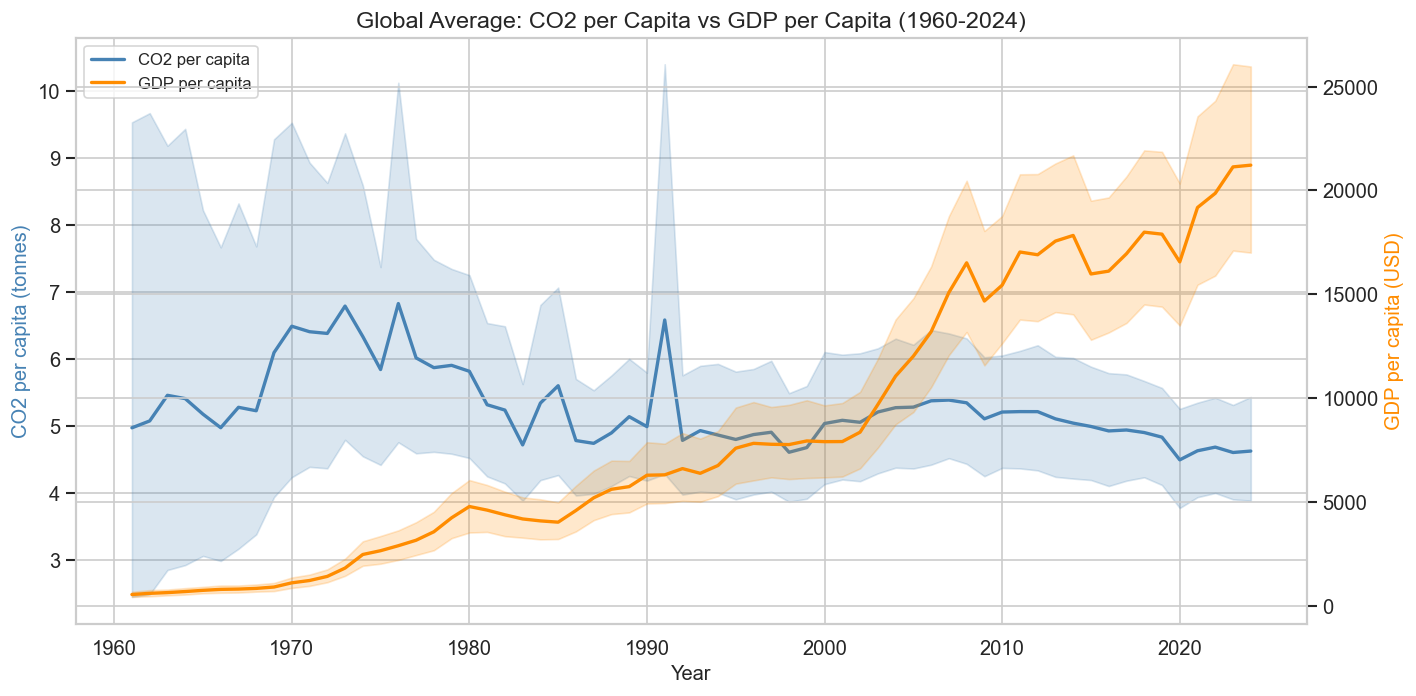

In [103]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.lineplot(ax=ax1, x='year', y='co2_per_capita', data=base_df,
             color='steelblue', linewidth=2, label='CO2 per capita')
sns.lineplot(ax=ax2, x='year', y='gdp_per_capita', data=base_df,
             color='darkorange', linewidth=2, label='GDP per capita')

ax1.set_xlabel('Year')
ax1.set_ylabel('CO2 per capita (tonnes)', color='steelblue')
ax2.set_ylabel('GDP per capita (USD)', color='darkorange')
ax1.set_title('Global Average: CO2 per Capita vs GDP per Capita (1960-2024)')

# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax2.get_legend().remove()

plt.tight_layout()
plt.show()

## Income Group Classification

To move beyond individual country case studies, we classify each observation by **income group** using the World Bank's Gross National Income (GNI) thresholds:

| Group | GNI per capita (current USD) |
|---|---|
| Low | $\leq$ 1,145 |
| Lower-Middle | 1,146 – 4,515 |
| Upper-Middle | 4,516 – 14,005 |
| High | $>$ 14,005 |

Source: [World Bank Country Classification (FY2025)](https://datahelpdesk.worldbank.org/knowledgebase/articles/906519-world-bank-country-and-lending-groups)

This allows us to ask a structural question: do emission trajectories differ systematically between rich and poor countries? We scrape current GNI per capita figures from Wikipedia and merge them onto our dataset.

In [104]:
# fetch data from wikipedia
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GNI_(nominal)_per_capita'

# use pandas becuase polars doesn't support html
tables = pd.read_html(url, storage_options={'User-Agent': 'Mozilla/5.0'})

# table 1 contains the GNI per capita data
gni_df = tables[1]

# rename cols
dict = {
    'Country': 'country',
    'GNI per capita (US$)[1][3]': 'gni_per_capita'
}

gni_df = gni_df.rename(columns=dict)
gni_df = pl.from_pandas(gni_df)

gni_df



Unnamed: 0,country,gni_per_capita,Year
str,str,f64,i64
null,"""High Income Economies""",null,2024
"""–""","""Bermuda (UK)""",145150.0,2024
"""1""","""Liechtenstein""",116600.0,2009
"""2""","""Norway""",98170.0,2024
"""3""","""Switzerland""",95220.0,2024
…,…,…,…
"""187""","""Madagascar""",510.0,2024
"""188""","""Yemen""",470.0,2024
"""189""","""Afghanistan""",370.0,2023


In [107]:
# normalize the colums for better merging
gni_df = gni_df.with_columns(normalize_column("country"))
base_df = base_df.with_columns(normalize_column("country"))


# left merge
main_df = base_df.join(gni_df.select(["gni_per_capita", "country_clean"]), on='country_clean', how='left')

# classify income groups using World Bank thresholds
main_df = main_df.with_columns(classify_income_group("gni_per_capita"))

main_df

country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,correlation,country_clean,gni_per_capita,income_group
str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,str
"""Afghanistan""",1961,"""AFG""",9214082,0.491,null,0.053288,null,null,0.051917,0.9157,"""afghanistan""",370.0,"""Low"""
"""Afghanistan""",1962,"""AFG""",9404410,0.689,null,0.073264,null,null,0.070704,0.9157,"""afghanistan""",370.0,"""Low"""
"""Afghanistan""",1963,"""AFG""",9604491,0.707,null,0.073611,null,null,0.071028,0.9157,"""afghanistan""",370.0,"""Low"""
"""Afghanistan""",1964,"""AFG""",9814317,0.839,null,0.085487,null,null,0.082029,0.9157,"""afghanistan""",370.0,"""Low"""
"""Afghanistan""",1965,"""AFG""",10036003,1.007,null,0.100339,null,null,0.095618,0.9157,"""afghanistan""",370.0,"""Low"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zimbabwe""",2020,"""ZWE""",15526887,8.491,3.1980e10,0.546858,2059.674586,7.630789,0.436226,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle"""
"""Zimbabwe""",2021,"""ZWE""",15797220,10.223,4.1288e10,0.647139,2613.603766,7.868868,0.49904,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle"""
"""Zimbabwe""",2022,"""ZWE""",16069061,12.232,4.0758e10,0.761214,2536.399713,7.838895,0.566004,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle"""


### Distribution of Income Groups (2024)

Before comparing emissions across income groups, we first check how many countries fall into each bracket in 2024. This serves as a sanity check - if one group is heavily overrepresented or nearly empty, later comparisons would be unreliable due to uneven sample sizes. The countplot also reflects the current structure of global economic inequality.

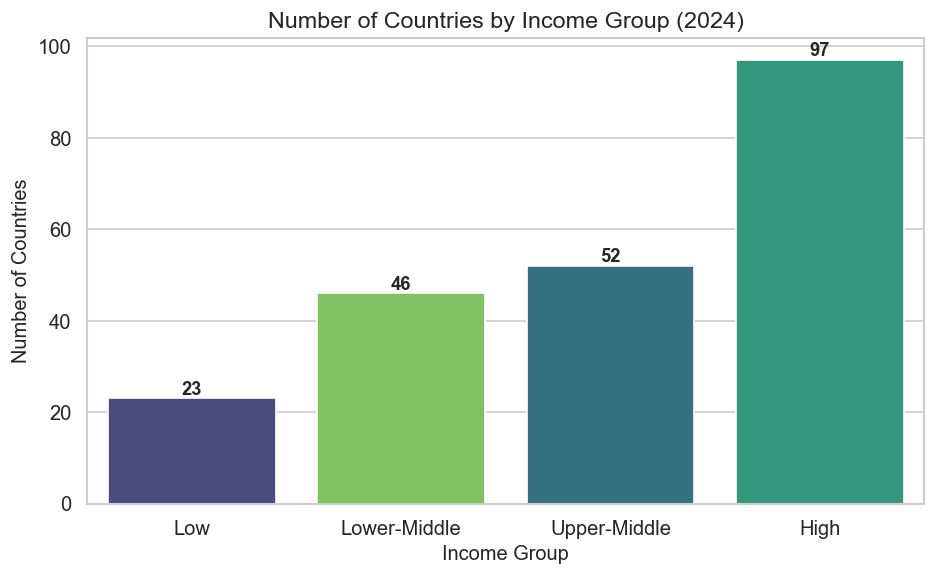

In [108]:
income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
df_2024 = main_df.filter(pl.col("year") == 2024)

# convert to pandas for visualization
df_2024_pd = df_2024.to_pandas()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_2024_pd, x='income_group', order=income_order, palette='viridis', ax=ax, hue ='income_group')

ax.set_title('Number of Countries by Income Group (2024)')
ax.set_xlabel('Income Group')
ax.set_ylabel('Number of Countries')

# annotate bar counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/61/7lw43jz92wn9qxlh9cdtg5z80000gn/T/ipykernel_25255/1945263651.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=ax1,


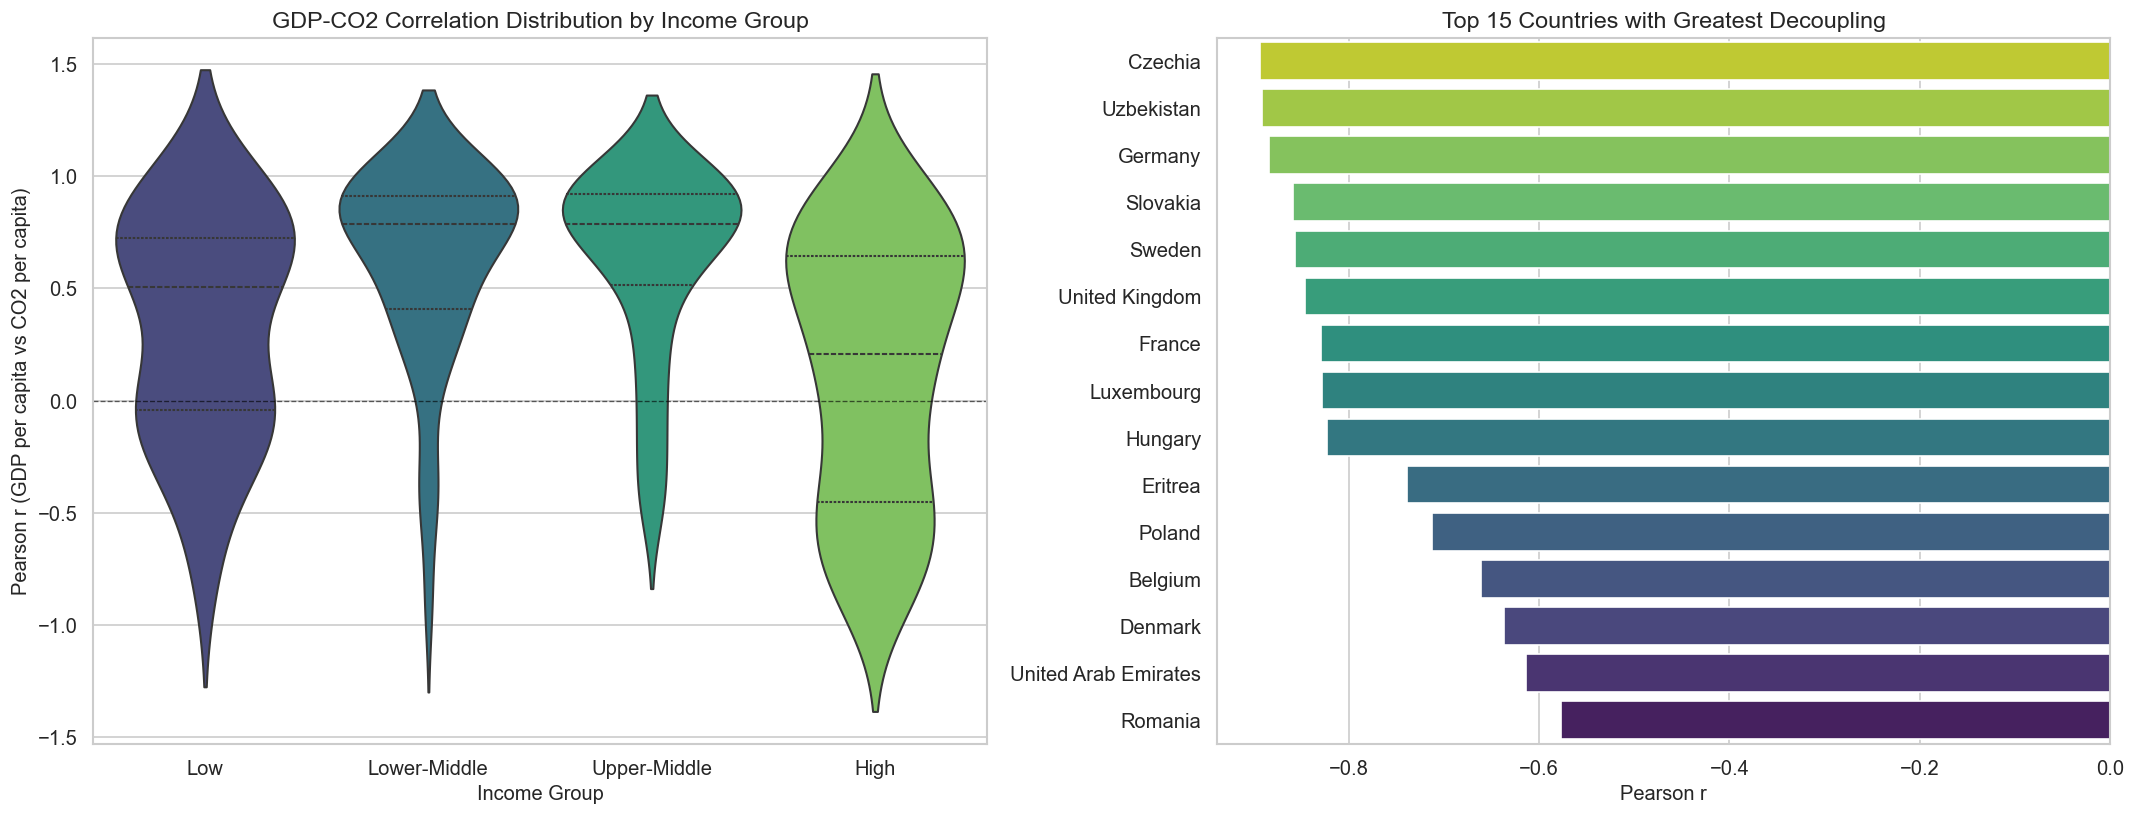

In [109]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# violin plot: correlation distribution by income group
income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']

sns.violinplot(ax=ax1, 
               x='income_group', 
               y='correlation', 
               data=df_2024_pd,
               order=income_order, 
               palette='viridis', 
               inner='quartile')

ax1.set_title('GDP-CO2 Correlation Distribution by Income Group')
ax1.set_xlabel('Income Group')
ax1.set_ylabel('Pearson r (GDP per capita vs CO2 per capita)')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

# bar chart: top 15 decouplers (most negative correlation)
top_decouplers = get_top_bottom_n(df_2024_pd, 'correlation', n=15)
sns.barplot(ax=ax2, 
            x='correlation', 
            y='country', 
            data=top_decouplers,
            palette='viridis_r', 
            hue='country')
            
ax2.set_title('Top 15 Countries with Greatest Decoupling')
ax2.set_xlabel('Pearson r')
ax2.set_ylabel('')
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# honestly I don't know how to get rid of this error message, I managed to fix it for every plot but nothing seems to work with the violin plot

### Interpreting the Results

The violin plot reveals how the GDP–CO2 correlation distributes within each income bracket. High-income countries show a wider spread with more negative correlations, suggesting that decoupling is more prevalent - and more varied - among wealthy nations. Lower-income groups cluster tightly around positive correlations, indicating that economic growth and emissions still move in tandem.

The bar chart of the top 15 decouplers (most negative Pearson r) surfaces some initially surprising entries - Uzbekistan and Czechia rank highly. However, this is consistent with the post-Soviet economic transition: many former Eastern Bloc countries experienced simultaneous GDP growth and emissions decline as they dismantled inefficient heavy industry inherited from the Soviet era and transitioned toward market economies with lighter industrial footprints.

The presence of the UAE among the top decouplers likely reflects its aggressive economic diversification away from oil dependency toward tourism, finance, and technology - sectors that generate GDP without proportional CO2 increases.

### Historical Emission Paths by Income Group
##### Note: Due to there not being a historical dataset I can't apply income groups to historical data. Income groups are referred to the current state of the countries 

The FacetGrid below plots per-capita CO2 over time, split into separate panels by income group. Each panel uses `sns.lineplot`, which computes the **mean** across all countries in that bracket along with a 95% confidence interval (shaded band).

We use separate panels rather than overlaying all four groups on a single axis for two reasons:
1. High-income countries emit orders of magnitude more per capita than low-income ones, which would compress the lower groups into flat lines at the bottom of a shared y-axis.
2. `sharey=False` gives each panel its own y-scale, allowing the internal trends within each group to be clearly visible.

**Key patterns to look for:**
- **High income**: A rise-then-decline trajectory - emissions peaked around the 1970s–2000s and have since been falling, consistent with deindustrialization, fuel switching, and policy intervention.
- **Upper-Middle**: Rapid growth phase, potentially still climbing as industrialization continues (driven heavily by China's trajectory in this bracket).
- **Lower-Middle / Low**: Flat, low emissions - these countries have contributed minimally to cumulative global CO2 despite housing large shares of the world's population.

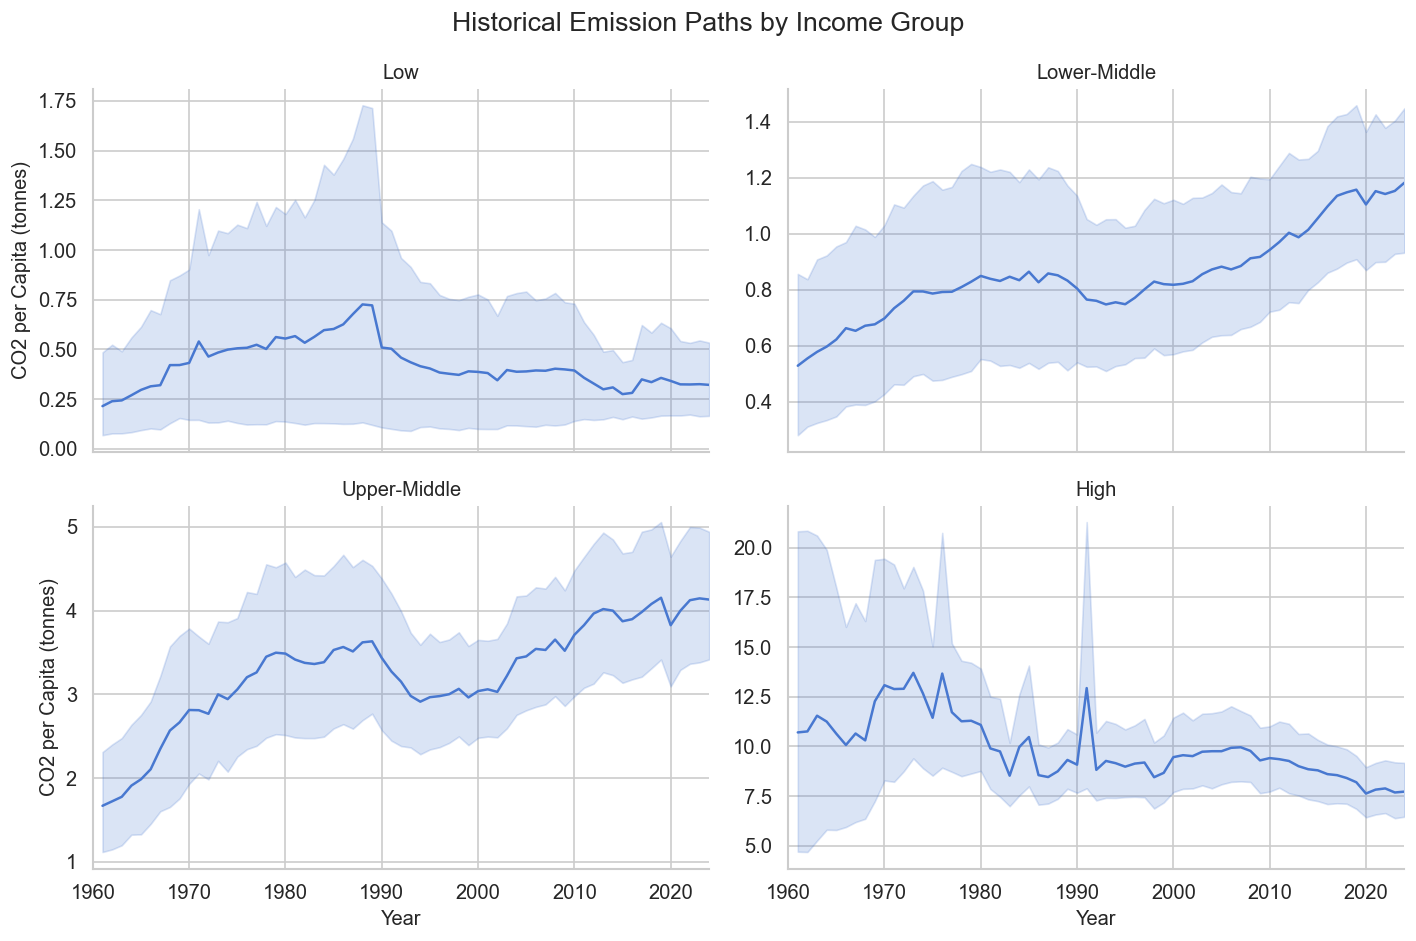

In [110]:
# compare historical emissions paths by income group
g = sns.FacetGrid(main_df, col="income_group", col_wrap=2, height=4, aspect=1.5,
                  sharey=False, col_order=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])
g.map(sns.lineplot, "year", "co2_per_capita")

g.set(xlim=(1960, 2024))
g.set_axis_labels("Year", "CO2 per Capita (tonnes)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Historical Emission Paths by Income Group", fontsize=16)
plt.show()

### Observations

The faceted emission trajectories confirm a clear structural divide:

- **High-income countries** show the classic inverted-U pattern (an Environmental Kuznets Curve shape) - emissions rose, peaked, and have since declined as economies shifted toward services and cleaner energy.
- **Upper-middle-income countries** display a notable growth. Mainly due to the rapid industrialization built on the basis of fossil fuels (China as main ambassador).
- **Lower-income groups** remain nearly flat throughout the entire period, underscoring the stark global inequality in both emissions responsibility and economic development.

This pattern supports the hypothesis that decoupling is largely a phenomenon of already-wealthy nations - those that have already passed through their most carbon-intensive growth phase.

In [111]:
# carbon intensity: CO2 (millions of tonnes) per $1M GDP
main_df = main_df.with_columns(
    pl.when(pl.col("gdp") != 0)
      .then(pl.col("co2") * 1_000_000 / pl.col("gdp"))
      .otherwise(None)
      .alias("co2_per_gdp"))

main_df

country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,correlation,country_clean,gni_per_capita,income_group,co2_per_gdp
str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64
"""Afghanistan""",1961,"""AFG""",9214082,0.491,null,0.053288,null,null,0.051917,0.9157,"""afghanistan""",370.0,"""Low""",null
"""Afghanistan""",1962,"""AFG""",9404410,0.689,null,0.073264,null,null,0.070704,0.9157,"""afghanistan""",370.0,"""Low""",null
"""Afghanistan""",1963,"""AFG""",9604491,0.707,null,0.073611,null,null,0.071028,0.9157,"""afghanistan""",370.0,"""Low""",null
"""Afghanistan""",1964,"""AFG""",9814317,0.839,null,0.085487,null,null,0.082029,0.9157,"""afghanistan""",370.0,"""Low""",null
"""Afghanistan""",1965,"""AFG""",10036003,1.007,null,0.100339,null,null,0.095618,0.9157,"""afghanistan""",370.0,"""Low""",null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zimbabwe""",2020,"""ZWE""",15526887,8.491,3.1980e10,0.546858,2059.674586,7.630789,0.436226,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle""",0.000266
"""Zimbabwe""",2021,"""ZWE""",15797220,10.223,4.1288e10,0.647139,2613.603766,7.868868,0.49904,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle""",0.000248
"""Zimbabwe""",2022,"""ZWE""",16069061,12.232,4.0758e10,0.761214,2536.399713,7.838895,0.566004,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle""",0.0003


# Carbon Intensity: CO2 per $1 Million GDP

CO2 per GDP is an indicator of how efficient an economy is in terms of emissions. Typically we observe a downward trend, as technological advancements make economies more efficient while emitting less CO2.

We might also assume that richer, high-income countries are often the most efficient, due to their abundance of technological advancements and investments into greener production.

Due to countries like China, or the former Soviet states being in the upper-middle category, we can also expect them to be among the most carbon-intensive economies.

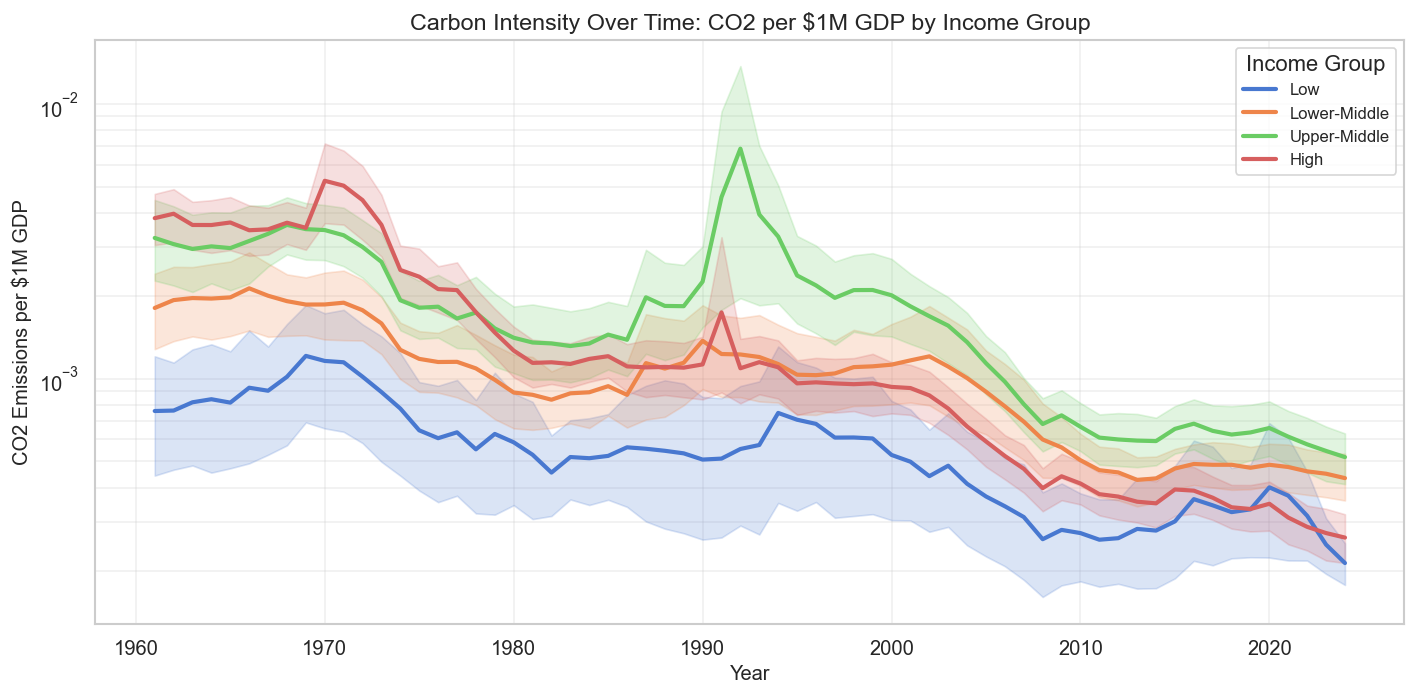

In [112]:
main_df_pd = main_df.to_pandas()

plt.figure(figsize=(12, 6))

sns.lineplot(data=main_df_pd, x='year', y='co2_per_gdp', hue='income_group',
             hue_order=['Low', 'Lower-Middle', 'Upper-Middle', 'High'],
             linewidth=2.5)

plt.yscale('log')
plt.title('Carbon Intensity Over Time: CO2 per $1M GDP by Income Group')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions per $1M GDP')
plt.legend(title='Income Group')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()

As expected we see the Upper-Middle Income Group as the dominating force since the 1980, mainly due to the post-soviet/communist economies and countries like China, still relying on fossil fuels. We see a decline across almost all income groups in terms of CO2 per GDP, showing that technological advancements overall helped us being more efficient, especially notable in high income groups, due to the resources available to become more efficient.

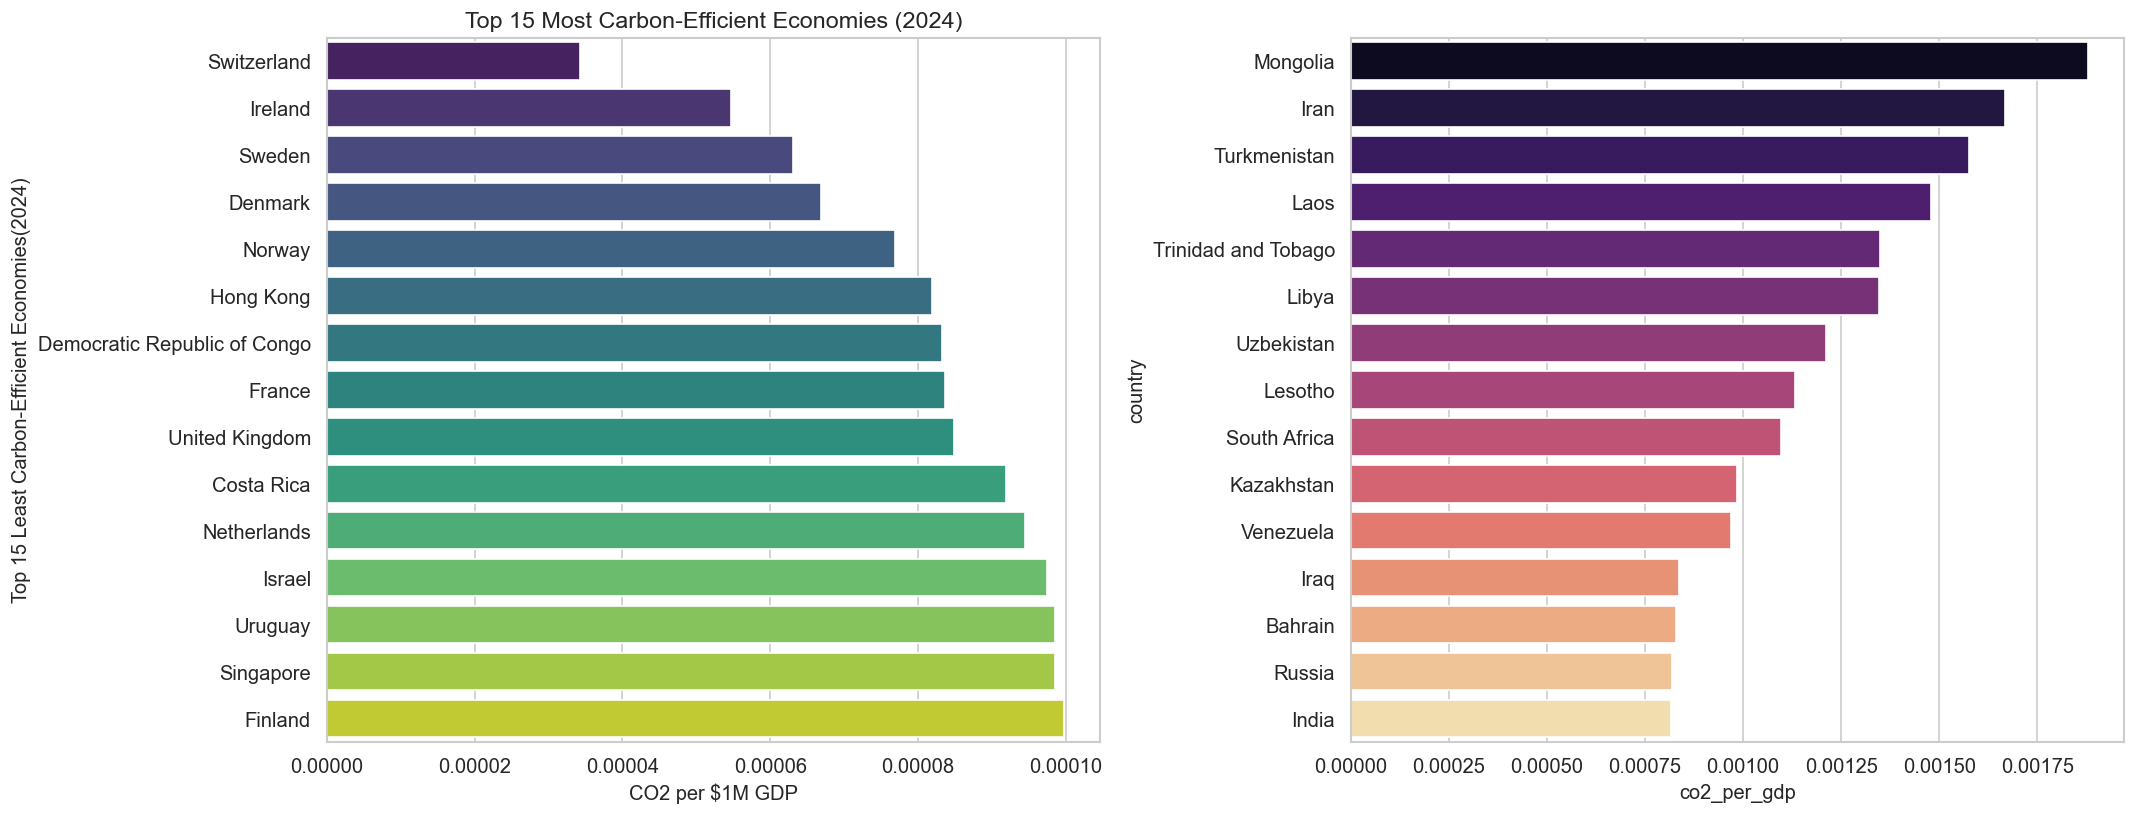

In [113]:
# filter: year 2024, population > 1M, valid co2_per_gdp
min_pop = 1_000_000
df_efficient = main_df.filter(pl.col("year") == 2024,
                              pl.col("population") > min_pop,
                              pl.col("co2_per_gdp") > 0)

base_df = base_df.with_columns(main_df.select(pl.col("co2_per_gdp")))
                       
# get the most and least efficient economies
df_efficient_pd = df_efficient.to_pandas()
most_efficient = get_top_bottom_n(df_efficient_pd, 'co2_per_gdp', n=15)
least_efficient = get_top_bottom_n(df_efficient_pd, 'co2_per_gdp', n=15, ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# plot the most and least efficient economies
sns.barplot(ax=ax1, 
            x='co2_per_gdp', 
            y='country', 
            data=most_efficient, 
            palette='viridis', 
            hue='country', 
            legend=False)
            
ax1.set_title('Top 15 Most Carbon-Efficient Economies (2024)')
ax1.set_xlabel('CO2 per $1M GDP')
ax1.set_ylabel('Top 15 Least Carbon-Efficient Economies(2024)')

sns.barplot(
    ax=ax2, 
    x='co2_per_gdp', 
    y='country', 
    data=least_efficient, 
    palette='magma',
    hue='country',  
    legend=False)

plt.tight_layout()
plt.show()

We can observe the most carbon efficient economies mainly consisting of western democracies and well-developed states. Exceptions are: DRC and Costa Rica, the DRC probably being there due to their poverty, as well as most energy coming from hydro-powerplants.

The least efficient economies consist of 6 post-communist states and a collection of economies reliant on oil, coal, or gas-powerplants. Except for potentially Russia all of those countries are deemed to be developmental economies.

# Z-Score outlier visualisation

In [114]:

df_z = (
    main_df
    # filter for year, min pop and co2 per gdp
    .filter(
        (pl.col("year") == 2024) &
        (pl.col("population") > min_pop) &
        (pl.col("co2_per_gdp") > 0)
    )
    # only choose country and co2 per gdp
    .select(["country", "co2_per_gdp"])
    # calculate sigma and mu and save as z-score
    .with_columns(
        (
            (pl.col("co2_per_gdp") - pl.col("co2_per_gdp").mean()) /
            pl.col("co2_per_gdp").std()
        ).alias("z_score")
    )
)

# classify each country by z-score band
df_z = df_z.with_columns(
                    pl.when(pl.col("z_score").abs() > 3).then(pl.lit('Extreme (|z|>3)'))
                    .when(pl.col("z_score").abs() > 2).then(pl.lit('Outlier (|z|>2)'))
                    .when(pl.col("z_score").abs() > 1).then(pl.lit('Moderate (|z|>1)'))
                    .otherwise(pl.lit('Normal (|z|≤1)'))
                    .alias("Band"))
# sort for plotting
df_z = df_z.sort(pl.col("z_score"))

df_z



country,co2_per_gdp,z_score,Band
str,f64,f64,str
"""Switzerland""",0.000034,-1.038032,"""Moderate (|z|>1)"""
"""Ireland""",0.000055,-0.978179,"""Normal (|z|≤1)"""
"""Sweden""",0.000063,-0.953521,"""Normal (|z|≤1)"""
"""Denmark""",0.000067,-0.942625,"""Normal (|z|≤1)"""
"""Norway""",0.000077,-0.913155,"""Normal (|z|≤1)"""
…,…,…,…
"""Trinidad and Tobago""",0.001349,2.811568,"""Outlier (|z|>2)"""
"""Laos""",0.001479,3.191275,"""Extreme (|z|>3)"""
"""Turkmenistan""",0.001576,3.477839,"""Extreme (|z|>3)"""


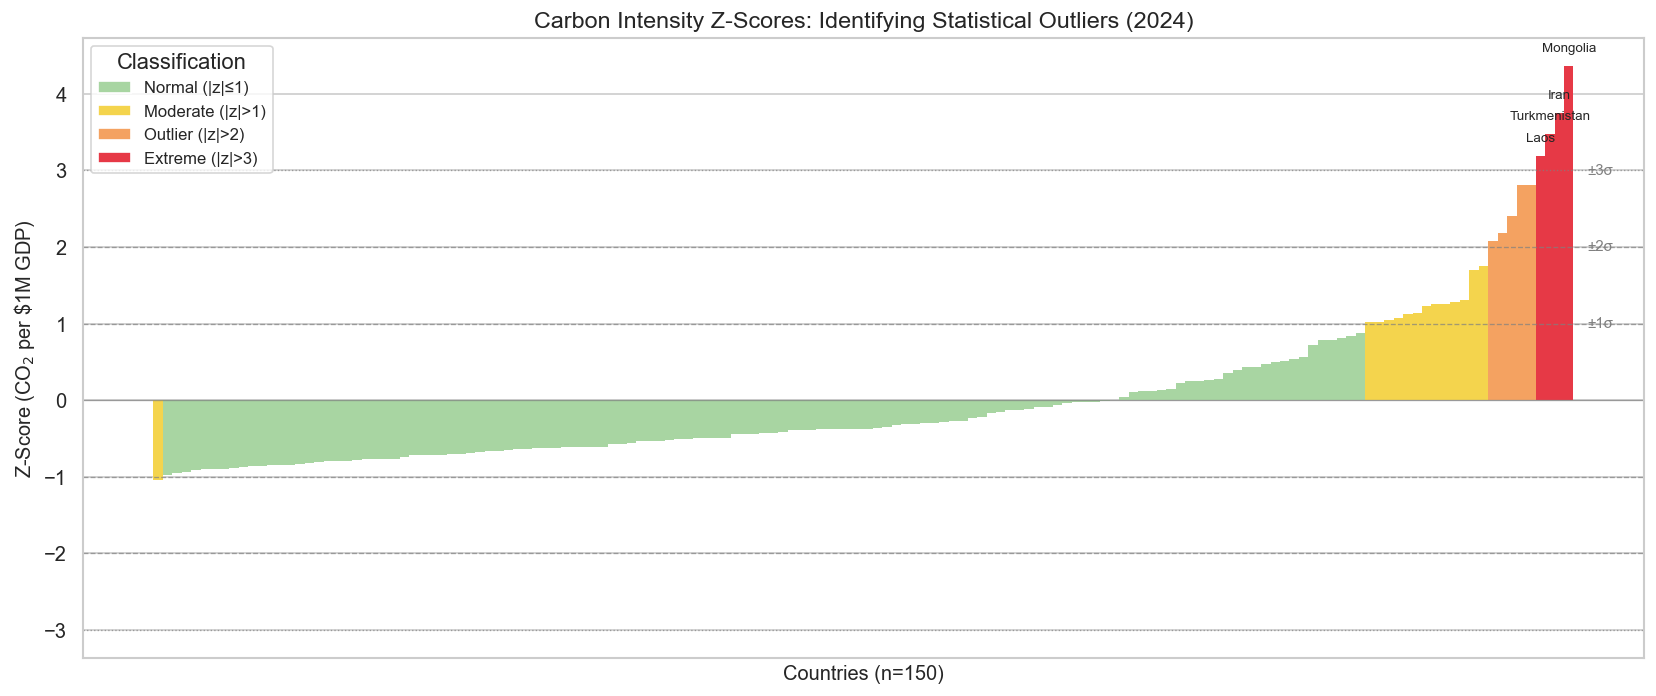

Outliers (|z|>2): 9 | Extreme (|z|>3): 4 of 150 countries


In [115]:
# convert to pandas for visualization
df_z_pd = df_z.to_pandas()

# plot
fig, ax = plt.subplots(figsize=(14, 6))

# create a palette for the bands
palette = {
    'Normal (|z|≤1)': '#a8d5a2',
    'Moderate (|z|>1)': '#f4d44d',
    'Outlier (|z|>2)': '#f4a261',
    'Extreme (|z|>3)': '#e63946'
}

ax.bar(range(len(df_z_pd)), df_z_pd['z_score'], color=df_z_pd['Band'].map(palette), width=1.0, edgecolor='none')

# z-score threshold bands
for z_val, ls, lbl in [(0, '-', 'Mean'), (1, '--', '±1σ'), (2, '--', '±2σ'), (3, ':', '±3σ')]:
    ax.axhline(z_val, color='grey', linestyle=ls, linewidth=0.8, alpha=0.7)
    if z_val > 0:
        ax.axhline(-z_val, color='grey', linestyle=ls, linewidth=0.8, alpha=0.7)
        ax.text(len(df_z_pd) + 1, z_val, lbl, va='center', fontsize=9, color='grey')

# label extreme outliers
for _, row in df_z_pd[np.abs(df_z_pd['z_score'].values) > 3].iterrows():
    idx = df_z_pd.index[df_z_pd['country'] == row['country']][0]
    ax.text(idx, row['z_score'] + np.sign(row['z_score']) * 0.15,
            row['country'], ha='center', va='bottom', fontsize=8)

ax.set_title('Carbon Intensity Z-Scores: Identifying Statistical Outliers (2024)')
ax.set_xlabel(f'Countries (n={len(df_z_pd)})')
ax.set_ylabel('Z-Score (CO$_2$ per \\$1M GDP)')
ax.set_xticks([])

# legend
legend_handles = [Patch(facecolor=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_handles, loc='upper left', title='Classification')

plt.tight_layout()
plt.show()

# summary statistics
n_outliers = np.sum(np.abs(df_z_pd['z_score'].values) > 2)
n_extreme = np.sum(np.abs(df_z_pd['z_score'].values) > 3)

print(f"Outliers (|z|>2): {n_outliers} | Extreme (|z|>3): {n_extreme} of {len(df_z)} countries")

### Interpreting Carbon Efficiency

**Most efficient economies** (lowest CO2 per $1M GDP):
Countries with service-dominated economies and minimal heavy industry naturally produce less CO2 per unit of economic output. Small island nations and financial centers top this list.

**Least efficient economies** (highest CO2 per $1M GDP):
Countries like Mongolia, Uzbekistan, Turkmenistan, and Kazakhstan are post-Soviet economies that rely heavily on coal for power generation - in some cases up to 90% of their electricity mix. This, combined with relatively low GDP, results in extremely high carbon intensity.

In [116]:

# fetch electricity production data from Our World in Data
df_electricity = pd.read_csv(
    "https://ourworldindata.org/grapher/electricity-prod-source-stacked.csv?v=1&csvType=full&useColumnShortNames=true",
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
df_electricity = pl.from_pandas(df_electricity)

# rename to concise column names
rename_map = {
    'code': 'iso_code',
    "other_renewables_excluding_bioenergy_generation__twh_chart_electricity_prod_source_stacked": "other_renewables",
    'bioenergy_generation__twh_chart_electricity_prod_source_stacked': 'bioenergy',
    'solar_generation__twh_chart_electricity_prod_source_stacked': 'solar',
    'wind_generation__twh_chart_electricity_prod_source_stacked': 'wind',
    'hydro_generation__twh_chart_electricity_prod_source_stacked': 'hydro',
    'nuclear_generation__twh_chart_electricity_prod_source_stacked': 'nuclear',
    'oil_generation__twh_chart_electricity_prod_source_stacked': 'oil',
    'gas_generation__twh_chart_electricity_prod_source_stacked': 'gas',
    'coal_generation__twh_chart_electricity_prod_source_stacked': 'coal',
}
df_electricity = df_electricity.rename(rename_map)

# keep only individual countries (drop aggregates without ISO codes)
df_electricity = df_electricity.filter(pl.col("iso_code").is_not_null())

df_electricity

entity,iso_code,year,other_renewables,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Afghanistan""","""AFG""",2000,0.0,0.0,0.0,0.0,0.31,0.0,0.17,0.0,0.0
"""Afghanistan""","""AFG""",2001,0.0,0.0,0.0,0.0,0.5,0.0,0.15,0.0,0.04
"""Afghanistan""","""AFG""",2002,0.0,0.0,0.0,0.0,0.56,0.0,0.11,0.0,0.04
"""Afghanistan""","""AFG""",2003,0.0,0.0,0.0,0.0,0.63,0.0,0.19,0.0,0.09
"""Afghanistan""","""AFG""",2004,0.0,0.0,0.0,0.0,0.56,0.0,0.17,0.0,0.06
…,…,…,…,…,…,…,…,…,…,…,…
"""Zimbabwe""","""ZWE""",2019,0.0,0.19,0.02,0.0,4.17,0.0,0.05,0.0,4.05
"""Zimbabwe""","""ZWE""",2020,0.0,0.1,0.02,0.0,3.81,0.0,0.04,0.0,2.74
"""Zimbabwe""","""ZWE""",2021,0.0,0.11,0.02,0.0,5.93,0.0,0.0,0.0,2.51


In [117]:
green_cols = ['other_renewables', 'bioenergy', 'solar', 'wind', 'hydro', 'nuclear']
non_green_cols = ['coal', 'oil', 'gas']

df_electricity = compute_energy_mix_shares(df_electricity, green_cols, non_green_cols)

df_electricity

entity,iso_code,year,other_renewables,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal,green_share,non_green_share
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Afghanistan""","""AFG""",2000,0.0,0.0,0.0,0.0,0.31,0.0,0.17,0.0,0.0,0.645833,0.354167
"""Afghanistan""","""AFG""",2001,0.0,0.0,0.0,0.0,0.5,0.0,0.15,0.0,0.04,0.724638,0.275362
"""Afghanistan""","""AFG""",2002,0.0,0.0,0.0,0.0,0.56,0.0,0.11,0.0,0.04,0.788732,0.211268
"""Afghanistan""","""AFG""",2003,0.0,0.0,0.0,0.0,0.63,0.0,0.19,0.0,0.09,0.692308,0.307692
"""Afghanistan""","""AFG""",2004,0.0,0.0,0.0,0.0,0.56,0.0,0.17,0.0,0.06,0.708861,0.291139
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zimbabwe""","""ZWE""",2019,0.0,0.19,0.02,0.0,4.17,0.0,0.05,0.0,4.05,0.516509,0.483491
"""Zimbabwe""","""ZWE""",2020,0.0,0.1,0.02,0.0,3.81,0.0,0.04,0.0,2.74,0.585693,0.414307
"""Zimbabwe""","""ZWE""",2021,0.0,0.11,0.02,0.0,5.93,0.0,0.0,0.0,2.51,0.707118,0.292882


In [118]:
# columns coming from df_electricity (excluding merge keys and entity)
elec_cols = [c for c in df_electricity.columns if c not in ['entity', 'iso_code', 'year']]

# merge electricity data onto base_df
base_df = base_df.join(
    df_electricity.drop('entity'),
    on=['iso_code', 'year'],
    how='inner'
)

base_df

country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,correlation,country_clean,co2_per_gdp,other_renewables,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal,green_share,non_green_share
str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Afghanistan""",2000,"""AFG""",20130334,1.047,3.5214e9,0.052011,174.930931,5.170091,0.050704,0.9157,"""afghanistan""",0.000297,0.0,0.0,0.0,0.0,0.31,0.0,0.17,0.0,0.0,0.645833,0.354167
"""Afghanistan""",2001,"""AFG""",20284303,1.069,2.8136e9,0.052701,138.706849,4.939546,0.051359,0.9157,"""afghanistan""",0.00038,0.0,0.0,0.0,0.0,0.5,0.0,0.15,0.0,0.04,0.724638,0.275362
"""Afghanistan""",2002,"""AFG""",21378123,1.341,3.8257e9,0.062728,178.954038,5.192701,0.060839,0.9157,"""afghanistan""",0.000351,0.0,0.0,0.0,0.0,0.56,0.0,0.11,0.0,0.04,0.788732,0.211268
"""Afghanistan""",2003,"""AFG""",22733053,1.56,4.5209e9,0.068623,198.871081,5.297673,0.06637,0.9157,"""afghanistan""",0.000345,0.0,0.0,0.0,0.0,0.63,0.0,0.19,0.0,0.09,0.692308,0.307692
"""Afghanistan""",2004,"""AFG""",23560656,1.237,5.2249e9,0.052503,221.763635,5.406111,0.051171,0.9157,"""afghanistan""",0.000237,0.0,0.0,0.0,0.0,0.56,0.0,0.17,0.0,0.06,0.708861,0.291139
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zimbabwe""",2019,"""ZWE""",15271377,10.267,3.3358e10,0.672303,2184.327951,7.689521,0.514202,-0.507579,"""zimbabwe""",0.000308,0.0,0.19,0.02,0.0,4.17,0.0,0.05,0.0,4.05,0.516509,0.483491
"""Zimbabwe""",2020,"""ZWE""",15526887,8.491,3.1980e10,0.546858,2059.674586,7.630789,0.436226,-0.507579,"""zimbabwe""",0.000266,0.0,0.1,0.02,0.0,3.81,0.0,0.04,0.0,2.74,0.585693,0.414307
"""Zimbabwe""",2021,"""ZWE""",15797220,10.223,4.1288e10,0.647139,2613.603766,7.868868,0.49904,-0.507579,"""zimbabwe""",0.000248,0.0,0.11,0.02,0.0,5.93,0.0,0.0,0.0,2.51,0.707118,0.292882


# Electricity Mix and Carbon Intensity

Even today, coal remains one of the most widely used sources of electricity globally. Due to its large CO2 footprint, many countries struggle with pollution and carbon emissions.

Especially former Soviet republics and countries in the Central Asian region capitalise on their vast coal reserves and use them as their primary source of electricity. That, combined with generally smaller populations, typically leads to higher CO2 per GDP. This relationship between electricity mix and carbon intensity is explored below.

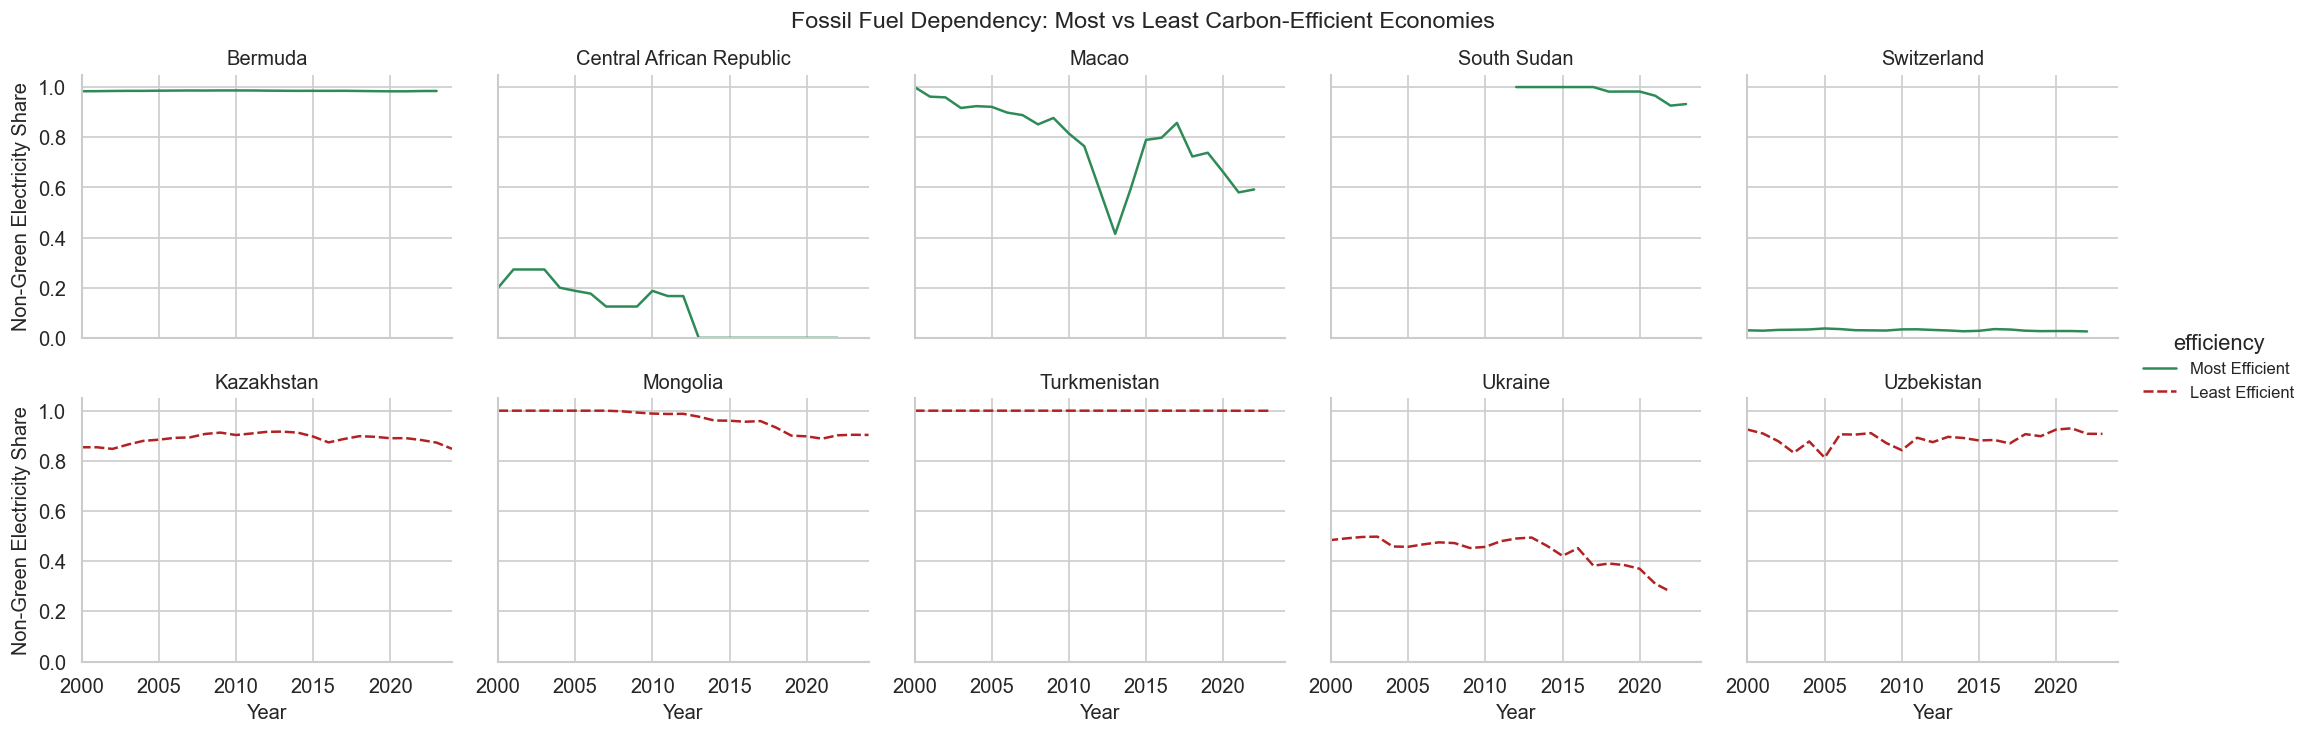

In [119]:
# only choose valid values
valid_efficiency = base_df.filter(pl.col("co2_per_gdp") > 0)

# calculate avg 
efficiency_rank = (
    valid_efficiency
    .group_by("iso_code")
    .agg(pl.col("co2_per_gdp").mean().alias("mean_co2_per_gdp")))

# take the most and least efficient
top5_efficient = (
    efficiency_rank
    .sort("mean_co2_per_gdp")
    .head(5)
    .get_column("iso_code")
    .to_list())

top5_inefficient = (
    efficiency_rank
    .sort("mean_co2_per_gdp", descending=True)
    .head(5)
    .get_column("iso_code")
    .to_list())

countries_to_plot = top5_efficient + top5_inefficient

# prepare plot data
plot_df = (
    base_df
    .filter(pl.col("iso_code").is_in(countries_to_plot))
    .with_columns(
        pl.when(pl.col("iso_code").is_in(top5_efficient))
        .then(pl.lit("Most Efficient"))
        .otherwise(pl.lit("Least Efficient"))
        .alias("efficiency")))

# choose order
efficient_countries = (
    plot_df
    .filter(pl.col("efficiency") == "Most Efficient")
    .select("country")
    .unique(maintain_order=True)
    .get_column("country")
    .to_list())

inefficient_countries = (
    plot_df
    .filter(pl.col("efficiency") == "Least Efficient")
    .select("country")
    .unique(maintain_order=True)
    .get_column("country")
    .to_list())

col_order = efficient_countries + inefficient_countries

# convert to pandas for seaborn
plot_df_pd = plot_df.to_pandas()

g = sns.relplot(
    data=plot_df_pd,
    x="year",
    y="non_green_share",
    hue="efficiency",
    style="efficiency",
    col="country",
    col_wrap=5,
    col_order=col_order,
    kind="line",
    height=3,
    aspect=1.2,
    palette={"Most Efficient": "seagreen", "Least Efficient": "firebrick"},
    facet_kws={"xlim": (2000, 2024), "ylim": (0, 1.05)},)

g.set_titles("{col_name}")
g.set_axis_labels("Year", "Non-Green Electricity Share")
g.fig.suptitle(
    "Fossil Fuel Dependency: Most vs Least Carbon-Efficient Economies",
    y=1.02,
    fontsize=14,)

plt.show()


### Electricity Mix: Key Observations

Looking at the most and least efficient countries in terms of CO2 per GDP, a clear trend emerges: the more efficient a country is, the lower its share of non-green energy.

However, several anomalies stand out:

- **Bermuda** has a ~100% non-green electricity share but is deemed carbon-efficient. This is because its exceptionally high GDP (driven by financial services) means that its modest electricity emissions barely register per dollar of output.
- **South Sudan** appears efficient for the opposite reason - most of the population lacks grid electricity entirely and relies on burning wood or waste, neither of which is captured in this dataset.
- **Ukraine**, despite not having the highest share of non-green electricity, struggles with carbon efficiency due to ageing Soviet-era industrial infrastructure and, more recently, the economic impact of the ongoing war. A declining population(and economy) also pushes CO2 per GDP upward.

# Energy-Usage per capita

### Integrating External XML Data

To demonstrate XML data processing, an additional dataset was retrieved
from the World Bank API containing energy consumption per capita.

The XML structure was parsed and converted into a pandas DataFrame.
Relevant fields were extracted and merged with the main dataset.

Energy consumption is conceptually related to carbon emissions and
therefore provides an additional explanatory variable for later
machine learning models.

In [120]:
# fetch xml data from worldbank.org(energy use per capita)
url = 'https://api.worldbank.org/v2/country/all/indicator/EG.USE.PCAP.KG.OE?format=xml&per_page=20000'

energy_xml = pd.read_xml(url)
energy_xml = pl.from_pandas(energy_xml)

energy_xml = energy_xml[[
    "countryiso3code",
    "date",
    "value"
]].rename({
    "countryiso3code": "iso_code",
    "date": "year",
    "value": "energy_use_pc"}
    )

energy_xml = energy_xml.with_columns(pl.col("year")
                                     .cast(pl.Int64))

energy_xml


iso_code,year,energy_use_pc
str,i64,f64
"""AFE""",2025,null
"""AFE""",2024,null
"""AFE""",2023,565.221624
"""AFE""",2022,568.382394
"""AFE""",2021,579.961579
…,…,…
"""ZWE""",1964,null
"""ZWE""",1963,null
"""ZWE""",1962,null


In [121]:
# merge
main_df = main_df.join(
    energy_xml,
    on=["iso_code","year"],
    how="left")

main_df

country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,correlation,country_clean,gni_per_capita,income_group,co2_per_gdp,energy_use_pc
str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64
"""Afghanistan""",1961,"""AFG""",9214082,0.491,null,0.053288,null,null,0.051917,0.9157,"""afghanistan""",370.0,"""Low""",null,null
"""Afghanistan""",1962,"""AFG""",9404410,0.689,null,0.073264,null,null,0.070704,0.9157,"""afghanistan""",370.0,"""Low""",null,null
"""Afghanistan""",1963,"""AFG""",9604491,0.707,null,0.073611,null,null,0.071028,0.9157,"""afghanistan""",370.0,"""Low""",null,null
"""Afghanistan""",1964,"""AFG""",9814317,0.839,null,0.085487,null,null,0.082029,0.9157,"""afghanistan""",370.0,"""Low""",null,null
"""Afghanistan""",1965,"""AFG""",10036003,1.007,null,0.100339,null,null,0.095618,0.9157,"""afghanistan""",370.0,"""Low""",null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Zimbabwe""",2020,"""ZWE""",15526887,8.491,3.1980e10,0.546858,2059.674586,7.630789,0.436226,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle""",0.000266,394.919241
"""Zimbabwe""",2021,"""ZWE""",15797220,10.223,4.1288e10,0.647139,2613.603766,7.868868,0.49904,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle""",0.000248,405.004501
"""Zimbabwe""",2022,"""ZWE""",16069061,12.232,4.0758e10,0.761214,2536.399713,7.838895,0.566004,-0.507579,"""zimbabwe""",2260.0,"""Lower-Middle""",0.0003,447.385983


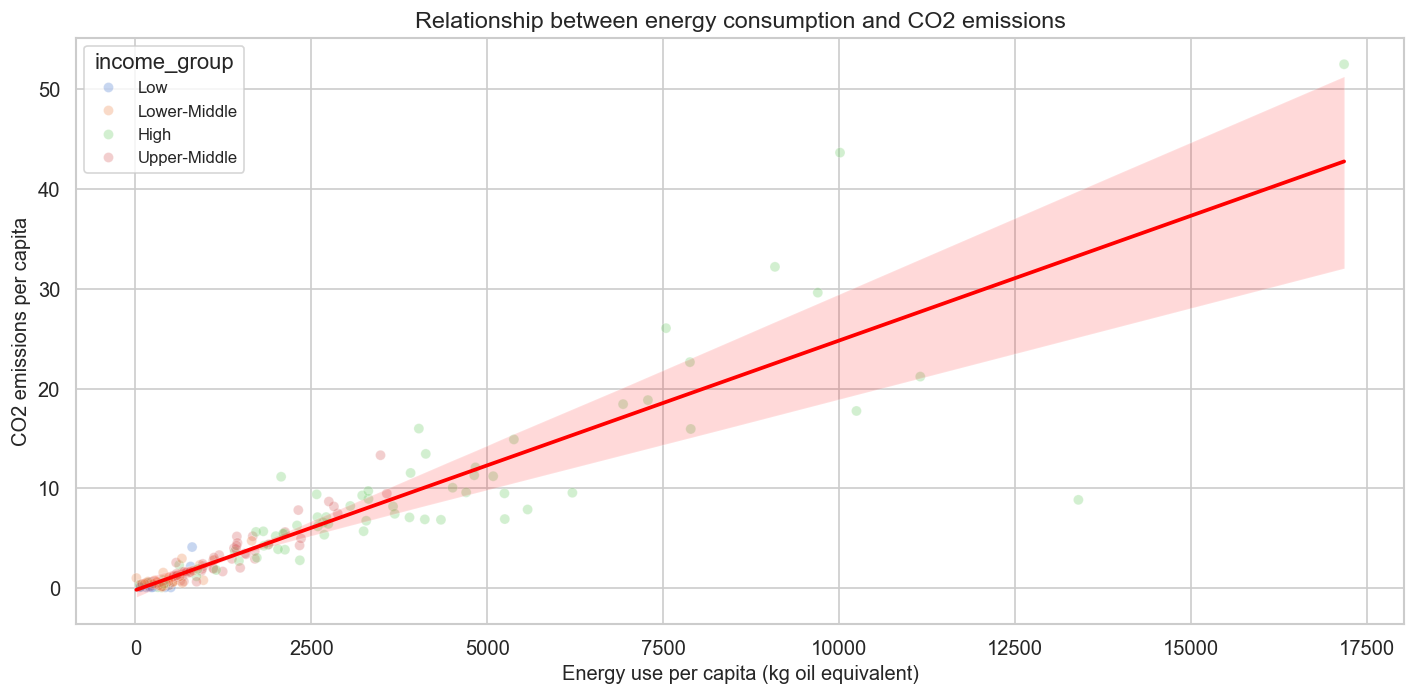

In [122]:
# mean the countries, so there are no duplicates from multiple years
mean_df = (
    main_df.group_by(["iso_code", "income_group"])
      .agg(pl.col("energy_use_pc").mean(),
           pl.col("co2_per_capita").mean(),
           pl.col("gdp_per_capita").mean()))


fig, ax = plt.subplots(figsize=(12, 6))

# plot a scatterplot to display energy use per capita and co2 per capita
sns.scatterplot(
    data=mean_df,
    x="energy_use_pc",
    y="co2_per_capita",
    hue="income_group",
    alpha=0.3,
    ax = ax)

# use a regression plot to show trends
sns.regplot(
    data=mean_df,
    x="energy_use_pc",
    y="co2_per_capita",
    scatter=False,
    color="red",
    ax = ax
)


plt.xlabel("Energy use per capita (kg oil equivalent)")
plt.ylabel("CO2 emissions per capita")
plt.title("Relationship between energy consumption and CO2 emissions")

plt.tight_layout()
plt.show()


# Correlation between energy usage and CO₂ emissions per capita

The country-level aggregation reveals a strong positive relationship between energy consumption per capita and CO₂ emissions per capita. This suggests that differences in energy demand across countries play a significant role in explaining variations in emissions.

High-income countries generally show higher energy consumption levels, while low-income countries cluster in the lower-left region of the plot. This pattern reflects the strong link between economic development, energy demand, and emissions.

To avoid distortions caused by extreme single-year observations, the dataset was aggregated at the country level by calculating mean values across all available years. This allows the visualisation to focus on structural differences between countries rather than short-term fluctuations.


# Unsupervised Clustering: Country Archetypes

The analyses above used predefined income brackets to group countries. But do countries **naturally** cluster into distinct profiles when we let the data decide? We apply **KMeans clustering** on three features from the most recent year (2023):

1. **GDP per capita** - economic wealth
2. **CO2 per $1M GDP** - carbon intensity of the economy
3. **Non-green electricity share** - fossil fuel dependency in the power sector

All features are standardised (z-scored) before clustering to prevent GDP per capita (measured in thousands of USD) from dominating the distance metric over shares (measured between 0 and 1).

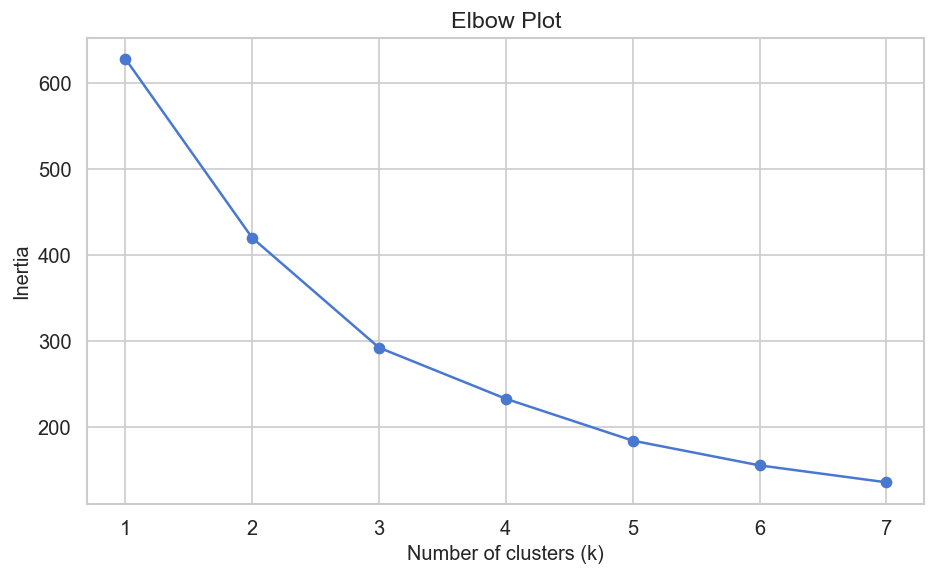

In [123]:
# choose a year and features
year = 2023
ml_features = ["log_gdp_pc", "log_co2_pc", "co2_per_gdp", "non_green_share"]

# prepare data for clustering
cluster_df = (
    base_df
    .filter(pl.col("year") == year)
    .select(["iso_code", "country", "year"] + ml_features)
    .with_columns([
        pl.when(pl.col(col).is_finite()).then(pl.col(col)).otherwise(None)
        for col in ml_features])
    .drop_nulls(subset=ml_features))

# run kmeans elbow ( in numpy)
X = cluster_df.select(ml_features).to_numpy()

# run kmeans elbow
fig, ax = plt.subplots(figsize=(8, 5))
_, scaled_data, _, inertias, scaler = run_kmeans_elbow(
    X,
    k_range=range(1, 8),
    scale=True,
    random_state=42,
    n_init=10,
    n_clusters=None,
    plot=True,
    ax=ax,)

plt.tight_layout()
plt.show()


### Choosing the Number of Clusters

The elbow plot shows inertia (within-cluster sum of squares) for k = 1 through 7. The "elbow" at **k = 3** indicates diminishing returns beyond four clusters, making it the optimal choice for segmenting countries by economic and environmental characteristics.

In [124]:
# Cluster countries
cluster_labels, scaled_data, kmeans_model, inertias, scaler = run_kmeans_elbow(
    X,
    k_range=range(1, 8),
    n_clusters=3,
    plot=False,
    ax=None,
    scale=True,
    random_state=42,
    n_init=10,)

# Add cluster labels to the original data
clustered_subset = cluster_df.with_columns(
    pl.Series("cluster", cluster_labels))

# Join cluster labels back to the original data
cluster_df = base_df.join(
    clustered_subset.select(["iso_code", "year", "cluster"]),
    on=["iso_code", "year"],
    how="left")

cluster_df = cluster_df.filter(pl.col("year") == year)

cluster_df

country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita,log_gdp_pc,log_co2_pc,correlation,country_clean,co2_per_gdp,other_renewables,bioenergy,solar,wind,hydro,nuclear,oil,gas,coal,green_share,non_green_share,cluster
str,i64,str,i64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32
"""Afghanistan""",2023,"""AFG""",41454762,10.516,1.7152e10,0.253674,413.757885,6.027695,0.226079,0.9157,"""afghanistan""",0.000613,0.0,0.0,0.09,0.0,0.75,0.0,0.1,0.0,0.03,0.865979,0.134021,0
"""Albania""",2023,"""ALB""",2811660,4.417,2.3491e10,1.570958,8354.9372,9.030728,0.944279,0.042977,"""albania""",0.000188,0.0,0.0,0.3,0.0,8.71,0.0,0.0,0.0,0.0,1.0,0.0,0
"""Algeria""",2023,"""DZA""",46164222,202.847,2.4792e11,4.394031,5370.476886,8.588858,1.685293,0.790378,"""algeria""",0.000818,0.0,0.0,0.87,0.02,0.02,0.0,0.39,95.0,0.0,0.00945,0.99055,2
"""Angola""",2023,"""AGO""",36749909,21.675,1.0717e11,0.589797,2916.136395,7.978358,0.463607,0.324559,"""angola""",0.000202,0.0,0.05,0.39,0.0,13.27,0.0,2.56,1.67,0.0,0.764214,0.235786,0
"""Antigua and Barbuda""",2023,"""ATG""",93331,0.641,2.0058e9,6.868029,21491.092833,9.97544,2.062808,0.665438,"""antigua and barbuda""",0.00032,0.0,0.0,0.02,0.0,0.0,0.0,0.34,0.0,0.0,0.055556,0.944444,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Venezuela""",2023,"""VEN""",28300861,119.588,1.0238e11,4.225596,3617.435051,8.193797,1.653569,0.14787,"""venezuela""",0.001168,0.0,0.0,0.01,0.02,64.98,0.0,5.8,12.13,0.0,0.78382,0.21618,2
"""Vietnam""",2023,"""VNM""",100352189,347.399,4.3386e11,3.461798,4323.350449,8.372017,1.495552,0.974364,"""vietnam""",0.000801,0.0,0.87,25.69,11.59,80.62,0.0,1.7,26.36,129.76,0.429408,0.570592,2
"""Yemen""",2023,"""YEM""",39390800,10.141,null,0.257446,null,null,0.229083,-0.050048,"""yemen""",null,0.0,0.0,0.52,0.0,0.0,0.0,2.0,0.55,0.0,0.169381,0.830619,null


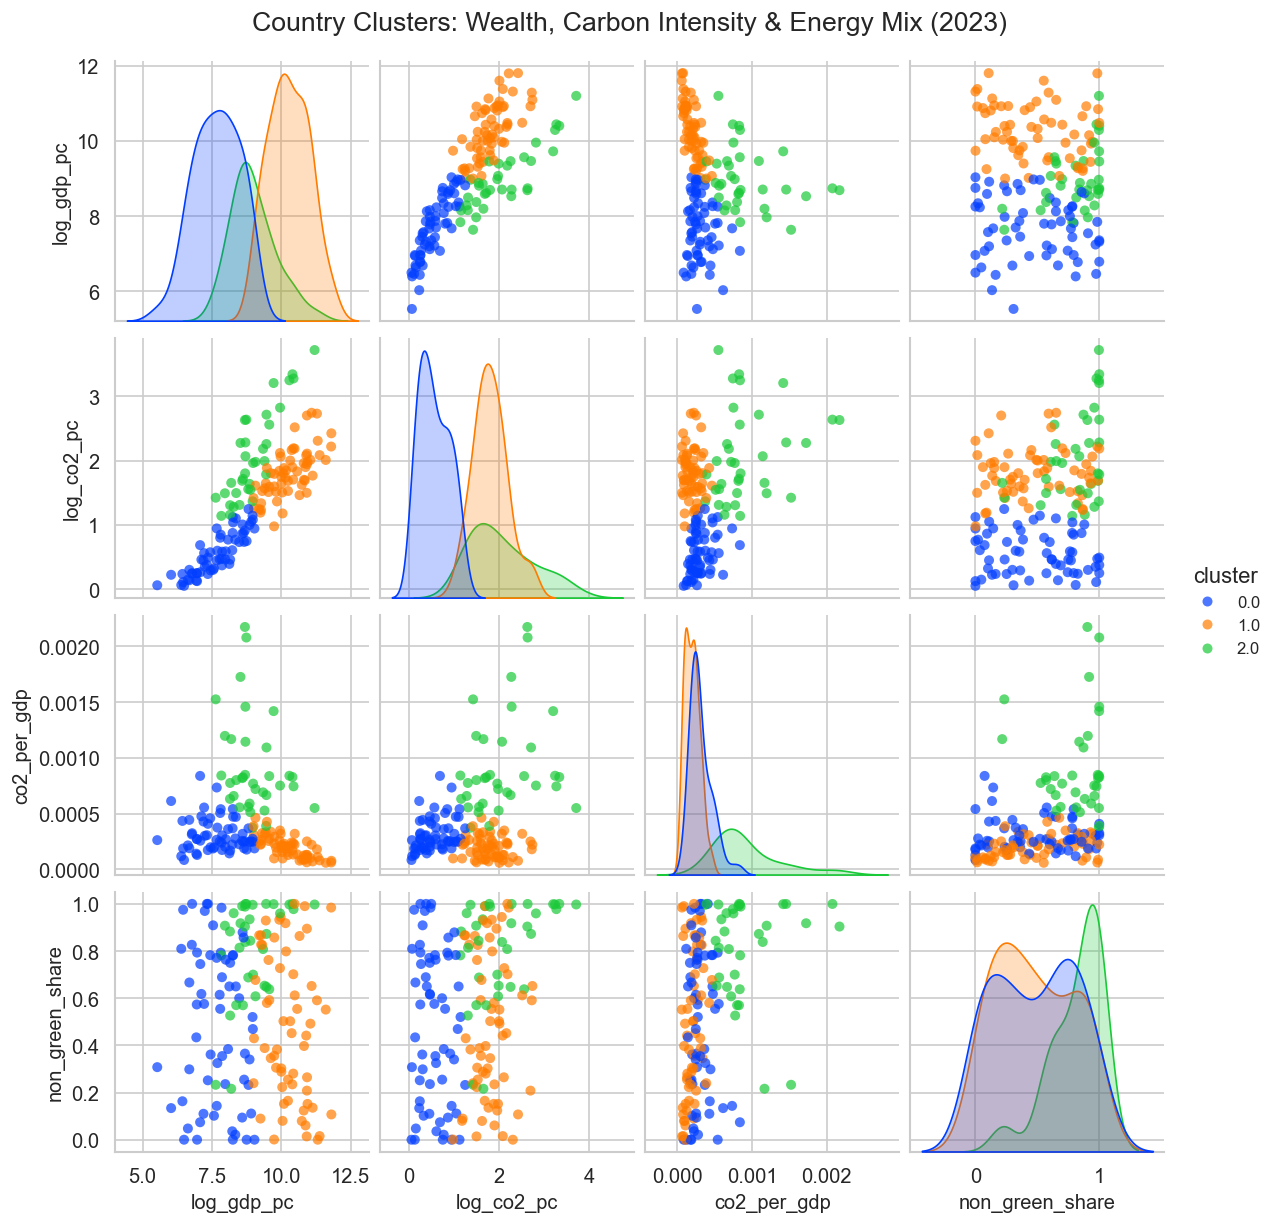

In [125]:
cluster_df_pd = cluster_df.to_pandas()
# create a pairplot of scatterplots
g = sns.pairplot(cluster_df_pd, vars=ml_features, hue='cluster', palette='bright',
                 diag_kind='kde', plot_kws={'alpha': 0.7, 'edgecolor': 'none'})
                 
g.fig.suptitle(f'Country Clusters: Wealth, Carbon Intensity & Energy Mix ({year})', y=1.02)
plt.show()

### Interpreting the Pairplot

The pairplot visualizes pairwise relationships between the three clustering features - GDP per capita, CO2 per $M GDP, and non-green electricity share - with each point colored by its KMeans cluster assignment.

- **GDP per capita vs. CO2 per GDP** shows a clear inverse relationship: wealthier countries tend to emit far less CO2 per unit of economic output, reinforcing the efficiency narrative from earlier sections.
- **Non-green share vs. CO2 per GDP** correlates positively - countries that rely heavily on fossil fuels for electricity are also the least carbon-efficient economies overall.
- **GDP per capita vs. non-green share** is more dispersed, suggesting that wealth alone does not guarantee a clean electricity mix (e.g. oil-rich Gulf states are wealthy but fossil-dependent).

The KDE diagonals reveal that most clusters are well-separated along at least one axis, confirming that the three-cluster solution captures meaningful structural differences rather than arbitrary splits.

# Further cluster analysis

While making assumptions is easy I'll look at the clusters in detail, finding out what exactly is behind the clusters and how effective Kmeans was.

In [126]:
ml_features = ["log_gdp_pc", "log_co2_pc", "co2_per_gdp", "non_green_share", "cluster"]

# clean data
cluster_df_clean = (
    cluster_df
    .select(["iso_code", "country"] + ml_features)
    .drop_nulls(subset=ml_features))

# scale data
X = cluster_df_clean.select(ml_features[0:4]).to_numpy()

X_scaled = StandardScaler().fit_transform(X)

# reduce dimensions
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,)

# transform data
embedding = reducer.fit_transform(X_scaled)

cluster_df_pd = cluster_df_clean.to_pandas().reset_index(drop=True)

cluster_df_pd

/Users/fabianfrank/Documents/carbon_analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,iso_code,country,log_gdp_pc,log_co2_pc,co2_per_gdp,non_green_share,cluster
0,AFG,Afghanistan,6.027695,0.226079,0.000613,0.134021,0
1,ALB,Albania,9.030728,0.944279,0.000188,0.000000,0
2,DZA,Algeria,8.588858,1.685293,0.000818,0.990550,2
3,AGO,Angola,7.978358,0.463607,0.000202,0.235786,0
4,ATG,Antigua and Barbuda,9.975440,2.062808,0.000320,0.944444,1
...,...,...,...,...,...,...,...
152,VUT,Vanuatu,8.155785,0.461673,0.000168,0.750000,0
153,VEN,Venezuela,8.193797,1.653569,0.001168,0.216180,2
154,VNM,Vietnam,8.372017,1.495552,0.000801,0.570592,2
155,ZMB,Zambia,7.194232,0.451639,0.000429,0.109969,0


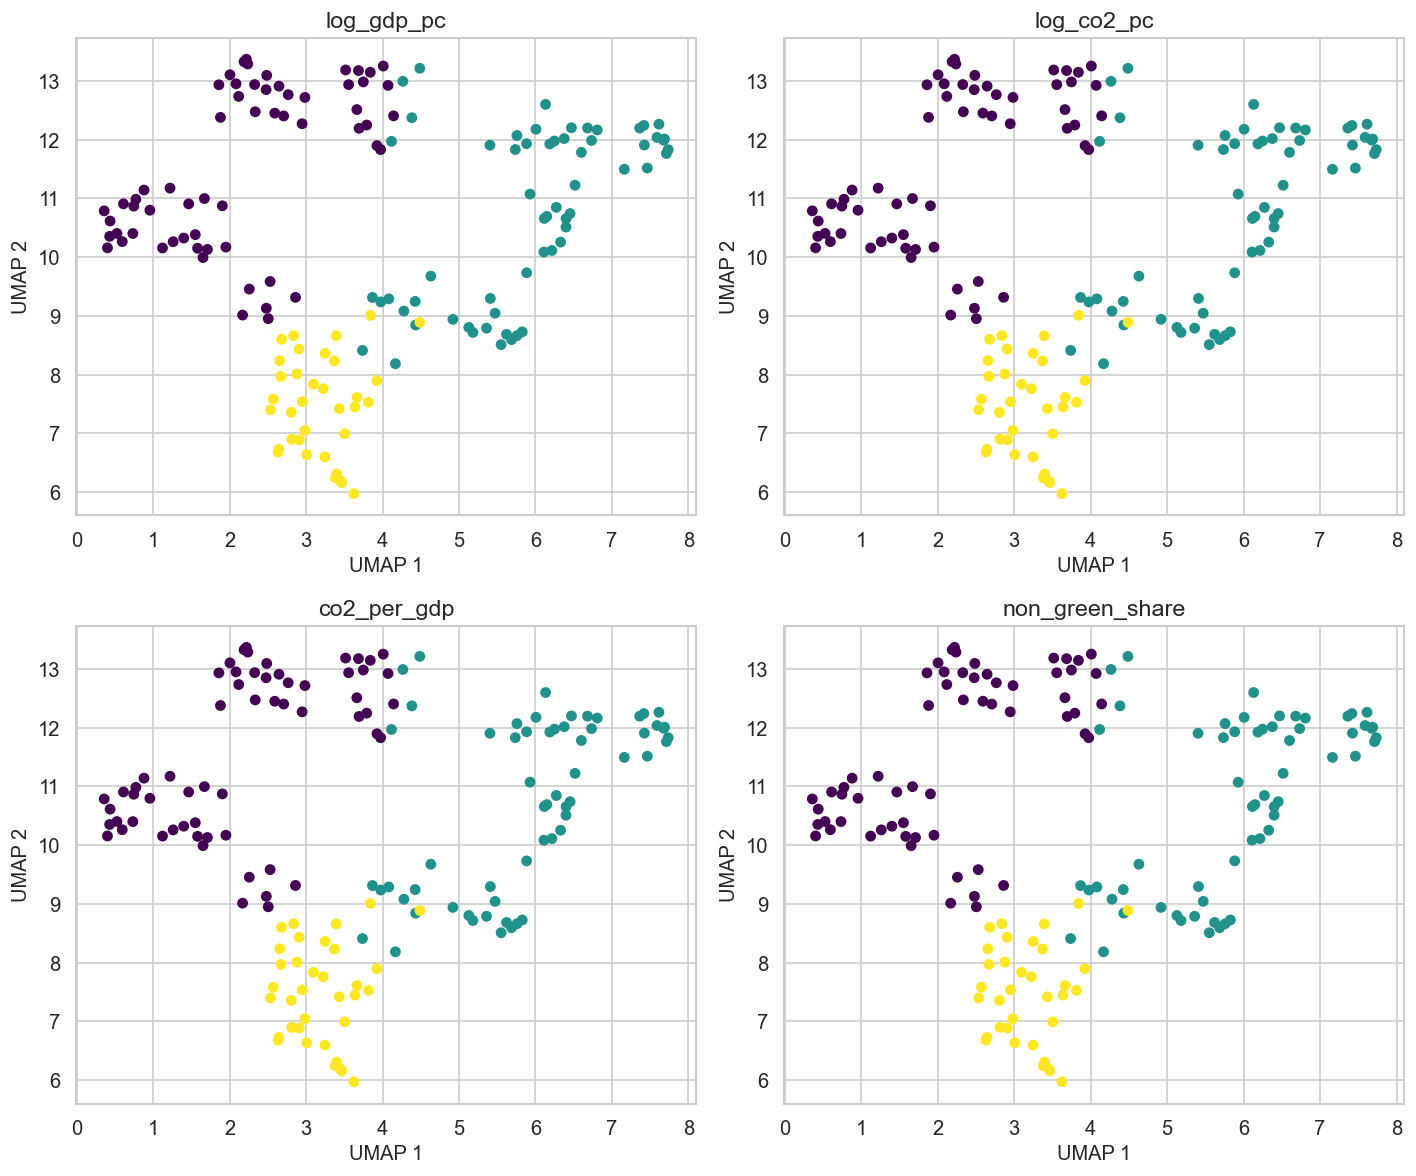

In [127]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# plot UMAP embeddings for each feature
for ax, feature in zip(axes.flatten(), ml_features):
    sc = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=cluster_df_pd["cluster"],
        cmap="viridis",
        s=30)
    ax.set_title(feature)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    
plt.tight_layout()
plt.show()

### UMAP analysis 
The UMAP visualization reveals a clear tension between economic growth and environmental sustainability. There is a visible positive correlation between wealth and emissions, as the clusters with the highest GDP per capita also show the highest carbon footprints. In contrast, the green share and non-green share plots act as near-perfect inverses; the points with the most significant sustainable activity are currently clustered in the lower-wealth regions. Ultimately, the data highlights a significant sustainability gap: the top-right clusters represent high-income but high-polluting entities, while the bottom-left reflects a greener but less wealthy profile, suggesting that a high-GDP, high-green-share model has not yet become a dominant reality.

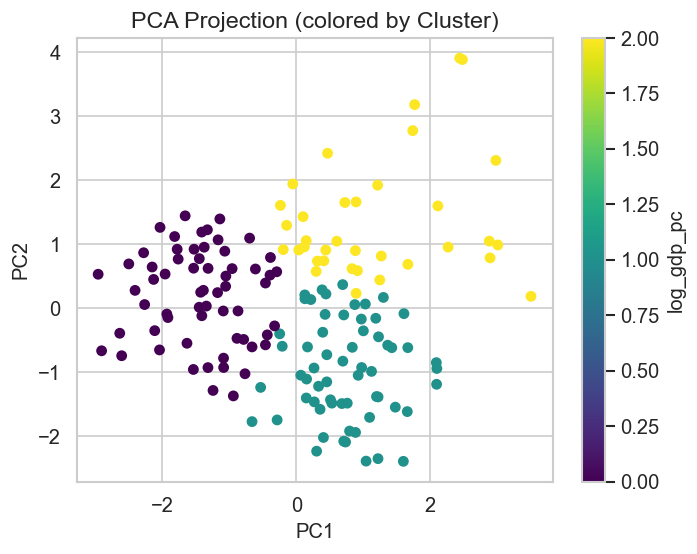

In [128]:
# extract main dimension (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# scatter them 
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_df_pd["cluster"],
    cmap="viridis",
    s=30)
    
plt.colorbar(label="log_gdp_pc")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (colored by Cluster)")
plt.show()

### What does this tell us about the data?
This shows us, that the main structure of the data is strongly dictated by the economic development of a country (Most importantly GDP per capita). High-income countries are clustered in the top-right corner, while low-income countries are clustered in the bottom center.

Sadly this means the dataset is mainly about economic development, while other features seem to be negligible.

In [129]:
pca.components_

array([[ 0.60137578,  0.71730126,  0.24059099,  0.25679184],
       [-0.46095623, -0.04591452,  0.67030959,  0.5797381 ]])

In [130]:
cluster_df_pd["cluster"] = cluster_labels

# create a mean for every feature in the clusters
cluster_summary = (
    cluster_df_pd
    .groupby("cluster")[ml_features]
    .mean())

print(cluster_summary)

         log_gdp_pc  log_co2_pc  co2_per_gdp  non_green_share  cluster
cluster                                                               
0          7.666011    0.559141     0.000310         0.484195      0.0
1         10.267926    1.804701     0.000198         0.474918      1.0
2          8.987800    2.071373     0.000917         0.812108      2.0


### More than just GDP?

In order to fact-check the conclusion of my PCA plot I decided to look at the values indivudually. We can actually see that the model trained more than purely GDP. It detected two dimensions:<br>
-**Wealth**: Cluster one is deemed welthy and efficient <br>
-**Energy and emmision efficiency**: Developmental countries like cluster 0 are low-income and inefficient, whereas cluster two depict very carbon-intensive economies



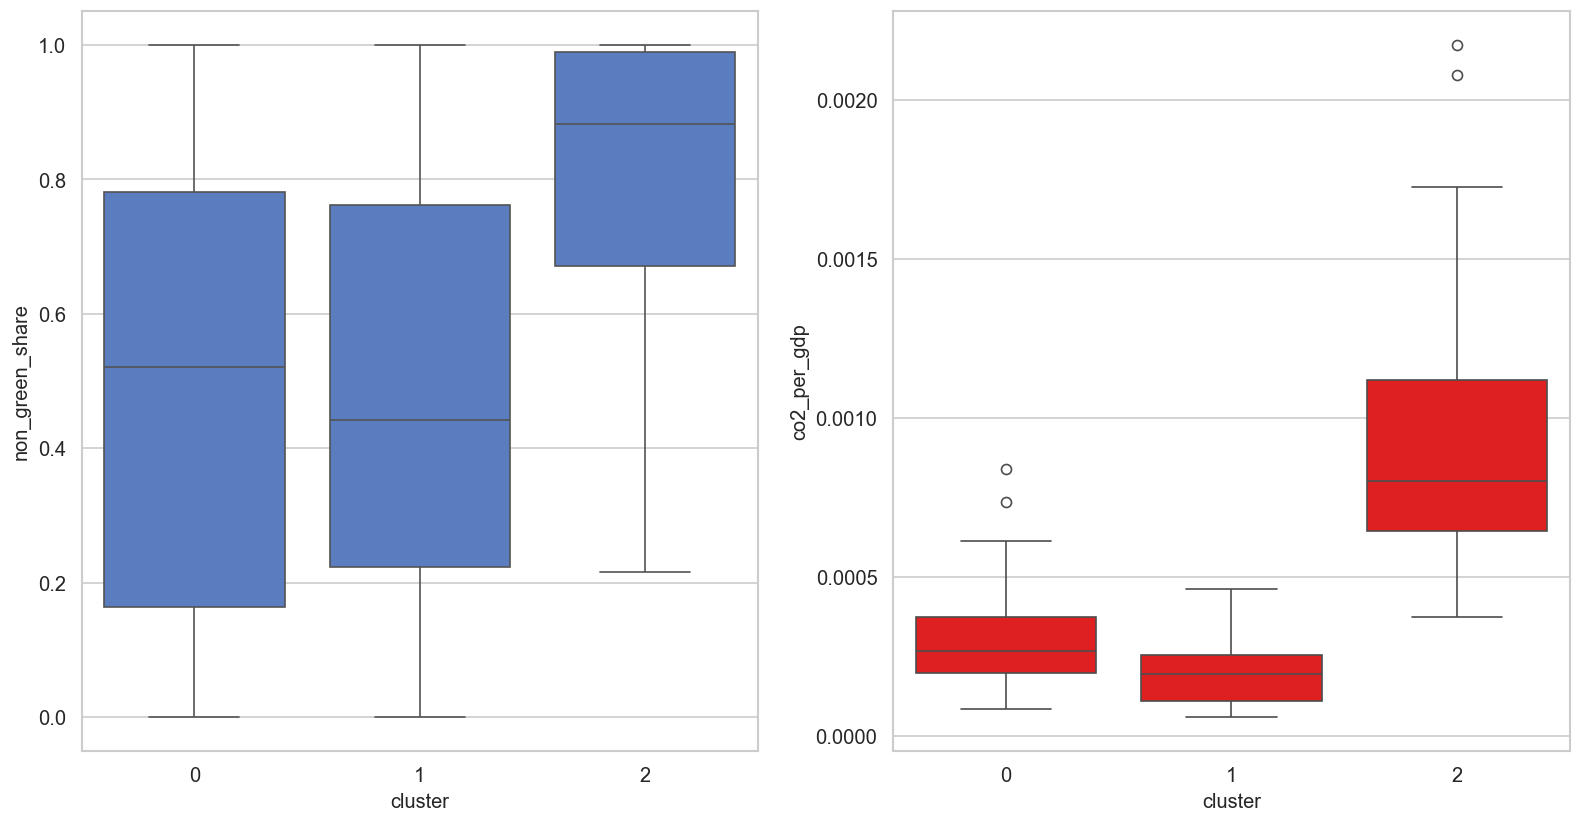

In [131]:
fig, (ax,ax2) = plt.subplots(1, 2,figsize=(16,8))

sns.boxplot(data=cluster_df_pd, x="cluster", y="non_green_share", ax=ax)
sns.boxplot(data=cluster_df_pd, x="cluster", y="co2_per_gdp", ax=ax2, color='red')
plt.show()

This plot confirms our thesis. Cluster 2 are carbon-intensive economies, therefore the model actually shows a structural difference. Due to cluster 0 and 2 being pretty similar it is likely that KMeans did not cluster by carbon intensity, further proving that economy is the main determining factor

But let's look closer at cluster 2:

In [132]:
# look at countries in cluster 2
cluster_df_pd[cluster_df_pd["cluster"] == 2].sort_values("co2_per_gdp", ascending=False)

,iso_code,country,log_gdp_pc,log_co2_pc,co2_per_gdp,non_green_share,cluster
95,MNG,Mongolia,8.686657,2.630042,0.002174,0.903919,2
146,TKM,Turkmenistan,8.737599,2.635981,0.002079,0.999704,2
71,IRN,Iran,8.527203,2.273695,0.001726,0.917884,2
81,LAO,Laos,7.634312,1.423493,0.001525,0.232887,2
85,LBY,Libya,8.704090,2.281393,0.001459,0.999715,2
143,TTO,Trinidad and Tobago,9.720748,3.204548,0.001419,0.998947,2
151,UZB,Uzbekistan,7.965535,1.492094,0.001197,0.907541,2
153,VEN,Venezuela,8.193797,1.653569,0.001168,0.216180,2
132,ZAF,South Africa,8.705376,2.067741,0.001145,0.838518,2
77,KAZ,Kazakhstan,9.463464,2.713131,0.001093,0.872700,2


You could have a look at the least efficient economies from earlier: They're pretty much the same. The model actually found a useful economical structure without being given earlier information.

Let's have a look at the efficiency of cluster 2 in comparison to cluster 0 and 1

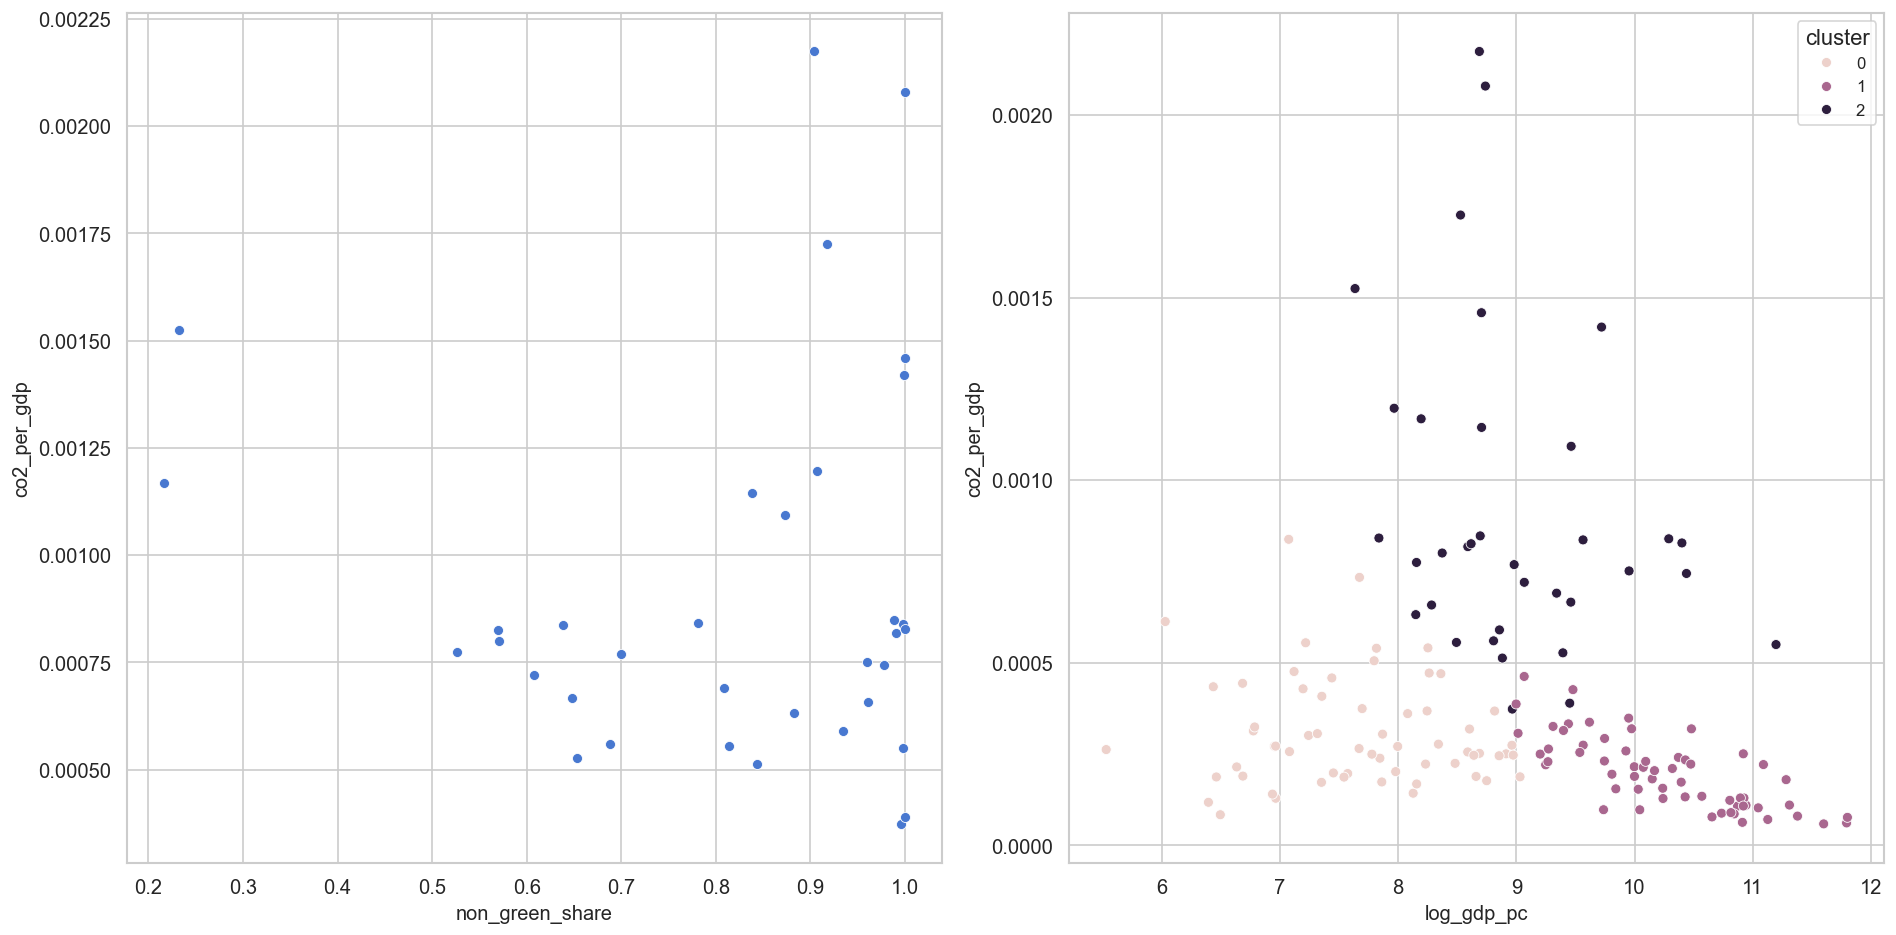

In [133]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(16,8))

# only look at cluster 2
cluster2 = cluster_df_pd[cluster_df_pd["cluster"] == 2]

# scatter
sns.scatterplot(
    data=cluster2,
    x="non_green_share",
    y="co2_per_gdp",
    ax=ax1)

sns.scatterplot(
    data=cluster_df_pd,
    x="log_gdp_pc",
    y="co2_per_gdp",
    hue="cluster",
    ax=ax2
)

plt.tight_layout()
plt.show()

This reaffirms the suspicions, that cluster two is a real economic phenomenon with low-efficiency economies, mostly being run on fossil fuels. Some countries in cluster two like Laos or Vietnam might not have a high non_green share, however this might be explainable by their post-communist/communist, low-efficient economies.

Therefore we can say, that the Carbon intensity of economy is not mainly determined by economies. Structural differences like the energy-mix, industry-profile also play a significant role.
